# Dự đoán Hỏng hóc Thiết bị CNC dưới Distribution Shift

**Bài tập cuối khoá — Machine Learning**  ·  Nhóm: `<điền tên/MSSV>`

Nhà máy vận hành đội máy phay CNC. Ta xây mô hình dự đoán **thiết bị sẽ hỏng trong ca kế tiếp**
(`hong_hoc` = 1) để chuyển từ bảo trì bị động sang **bảo trì chủ động (predictive maintenance)**.

Điểm mấu chốt: dữ liệu huấn luyện và kiểm thử đến từ **hai dây chuyền khác điều kiện vận hành**:

| Tập | Dây chuyền | Đặc điểm |
|-----|-----------|----------|
| **Train** | A — nhà máy cũ | vận hành ~2 năm, cảm biến hiệu chỉnh chuẩn |
| **Test** | B — nhà máy mới | khí hậu nóng hơn, cảm biến vừa hiệu chỉnh, chế độ tải khác |

→ **Distribution shift là có thật**: cùng cơ chế vật lý gây hỏng, nhưng phân phối biến đầu vào bị dịch.
Toàn bộ chiến lược của notebook này xoay quanh việc **phát hiện – định lượng – bù trừ shift** để mô
hình còn tốt khi triển khai trên Dây chuyền B.

### Chiến lược: experiment-driven
Thay vì làm một lượt, ta **thử nhiều version** (v0, v1, …), tất cả chấm bằng **cùng một hàm đánh
giá** và ghi vào một **leaderboard** để so sánh khách quan; giữ cái tăng điểm, bỏ cái không — rồi
**hợp nhất nhiều mô hình (ensemble/stacking)** để đẩy độ chính xác lên tối đa.


## 0. Setup — thư viện, dữ liệu, quy ước cột

In [1]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import (roc_auc_score, average_precision_score,
                                   f1_score, precision_score, recall_score,
                                   precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# Train = Day chuyen A (nha may cu) ; Test = Day chuyen B (nha may moi, nong hon)
import os
_CANDS = ['Data_Final/Data_Final', 'Data_Final', '../Data_Final/Data_Final', '../Data_Final', '.']
_DIR = next((d for d in _CANDS if os.path.exists(os.path.join(d, 'train.csv'))
             and os.path.exists(os.path.join(d, 'test.csv'))), None)
assert _DIR is not None, 'Khong tim thay train.csv/test.csv'
train = pd.read_csv(os.path.join(_DIR, 'train.csv'))
test  = pd.read_csv(os.path.join(_DIR, 'test.csv'))

TARGET   = 'hong_hoc'
NUM_COLS = ['nhiet_do_moi_truong', 'nhiet_do_quy_trinh', 'toc_do_quay',
            'momen_xoan', 'do_mon_dao']
CAT_COLS = ['loai_san_pham', 'ca_lam_viec']

X_train_raw, y_train = train[NUM_COLS + CAT_COLS], train[TARGET]
X_test_raw,  y_test  = test[NUM_COLS + CAT_COLS],  test[TARGET]

print(f'Train (Day chuyen A): {train.shape}  |  ti le hong = {y_train.mean():.2%}')
print(f'Test  (Day chuyen B): {test.shape}   |  ti le hong = {y_test.mean():.2%}')
print(f'Missing values: train={train.isna().sum().sum()}, test={test.isna().sum().sum()}')


Train (Day chuyen A): (14000, 8)  |  ti le hong = 7.36%
Test  (Day chuyen B): (6000, 8)   |  ti le hong = 7.95%
Missing values: train=0, test=0


## 1. Phân tích khám phá dữ liệu (EDA)

Mục tiêu EDA ở bài này **khác thường lệ**: ngoài việc hiểu dữ liệu, ta phải **nhìn tận mắt
distribution shift** giữa Dây chuyền A (Train) và Dây chuyền B (Test), vì đó là trục chấm điểm
nặng nhất. Ta lần lượt trả lời 4 câu hỏi:

1. Nhãn mất cân bằng tới đâu, và train/test có lệch tỉ lệ hỏng không?
2. Biến đầu vào **dịch chuyển** thế nào từ A → B? (covariate shift)
3. Biến nào **thật sự phân tách** máy hỏng / không hỏng?
4. Các biến phân loại (loại sản phẩm, ca làm việc) có liên quan hỏng hóc không?


### 1.1 Mất cân bằng nhãn — và tỉ lệ hỏng train vs test

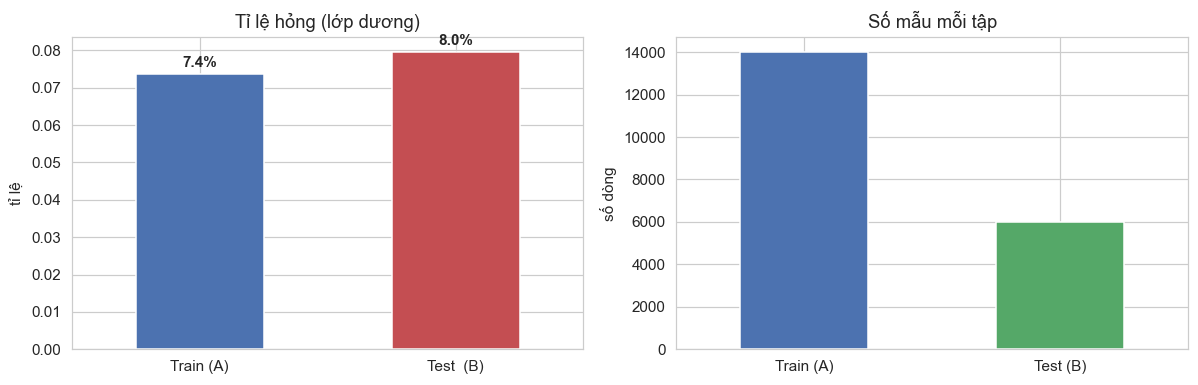

Train: 7.36% hỏng  (1031/14000)
Test : 7.95% hỏng  (477/6000)


In [2]:
# Ti le hong o hai day chuyen
rates = pd.DataFrame({
    'Train (A)': y_train.value_counts(normalize=True).sort_index(),
    'Test  (B)': y_test.value_counts(normalize=True).sort_index(),
}).T
rates.columns = ['khong_hong (0)', 'hong (1)']

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
rates['hong (1)'].plot.bar(ax=ax[0], color=['#4C72B0', '#C44E52'], rot=0)
ax[0].set_title('Tỉ lệ hỏng (lớp dương)'); ax[0].set_ylabel('tỉ lệ')
for i, v in enumerate(rates['hong (1)']):
    ax[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontweight='bold')

pd.Series({'Train (A)': len(y_train), 'Test (B)': len(y_test)}).plot.bar(
    ax=ax[1], color=['#4C72B0', '#55A868'], rot=0)
ax[1].set_title('Số mẫu mỗi tập'); ax[1].set_ylabel('số dòng')
plt.tight_layout(); plt.show()

print(f'Train: {y_train.mean():.2%} hỏng  ({y_train.sum()}/{len(y_train)})')
print(f'Test : {y_test.mean():.2%} hỏng  ({y_test.sum()}/{len(y_test)})')


**Nhận xét.** Cả hai tập đều **mất cân bằng nặng** (~7–8% hỏng), nên *accuracy vô nghĩa*
— ta sẽ chấm bằng **AUC-ROC, AUC-PR, F1/Precision/Recall** ở lớp dương. Tỉ lệ hỏng gần như
không đổi (7.4% → 8.0%): **prior của nhãn ổn định**, tức shift chủ yếu nằm ở *biến đầu vào*
(covariate shift) chứ không phải ở tỉ lệ hỏng (prior/label shift). Đây là manh mối định hướng:
ưu tiên **Importance Reweighting theo đặc trưng đầu vào**.


### 1.2 Covariate shift — chồng phân phối biến số Train vs Test

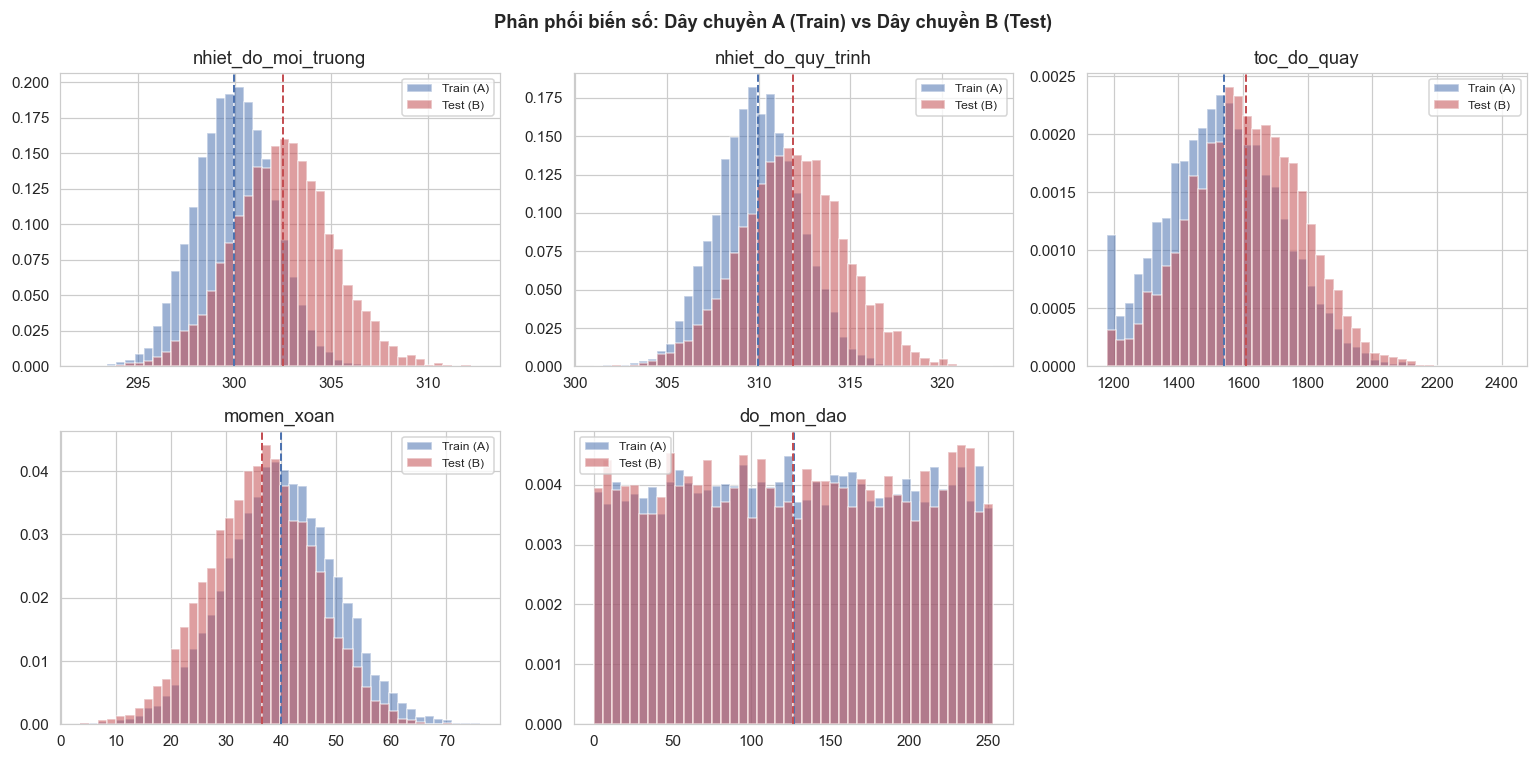

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM_COLS):
    lo = min(train[col].min(), test[col].min())
    hi = max(train[col].max(), test[col].max())
    bins = np.linspace(lo, hi, 45)
    ax.hist(train[col], bins=bins, density=True, alpha=0.55,
            color='#4C72B0', label='Train (A)')
    ax.hist(test[col],  bins=bins, density=True, alpha=0.55,
            color='#C44E52', label='Test (B)')
    ax.axvline(train[col].mean(), color='#4C72B0', ls='--', lw=1.3)
    ax.axvline(test[col].mean(),  color='#C44E52', ls='--', lw=1.3)
    ax.set_title(col); ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Phân phối biến số: Dây chuyền A (Train) vs Dây chuyền B (Test)',
             fontweight='bold'); plt.tight_layout(); plt.show()


In [4]:
# Bang dinh luong dich chuyen mean/std tu A -> B
shift = pd.DataFrame({
    'mean_A': train[NUM_COLS].mean(), 'mean_B': test[NUM_COLS].mean(),
    'std_A':  train[NUM_COLS].std(),  'std_B':  test[NUM_COLS].std(),
})
shift['Δmean']   = shift['mean_B'] - shift['mean_A']
shift['Δmean_%'] = 100 * shift['Δmean'] / shift['mean_A']
shift['Δstd_%']  = 100 * (shift['std_B'] - shift['std_A']) / shift['std_A']
shift.round(2)


,mean_A,mean_B,std_A,std_B,Δmean,Δmean_%,Δstd_%
nhiet_do_moi_truong,299.99,302.51,1.99,2.58,2.51,0.84,29.42
nhiet_do_quy_trinh,309.98,311.89,2.23,2.85,1.91,0.62,28.02
toc_do_quay,1540.26,1610.22,174.64,172.90,69.95,4.54,-1.00
momen_xoan,39.94,36.57,9.96,9.58,-3.37,-8.45,-3.84
do_mon_dao,126.95,126.58,72.69,73.36,-0.36,-0.29,0.92


**Nhận xét — shift là CÓ THẬT và có hướng vật lý rõ ràng.** Từ A → B:

- **nhiệt độ môi trường** +2.5°, **nhiệt độ quy trình** +1.9° → Dây chuyền B **nóng hơn** (đúng mô tả nhà máy mới, khí hậu nóng).
- **tốc độ quay** +70 vòng/phút → chế độ chạy **nhanh hơn**.
- **mômen xoắn** −3.4 (≈ −8%) → tải/mômen **thấp hơn** (hệ quả cơ học của việc chạy nhanh hơn).
- **độ mòn dao** gần như **không đổi** (mean ~127).
- Đáng chú ý: **độ lệch chuẩn nhiệt độ ở B rộng hơn ~28–30%** → B không chỉ *dịch* mà còn *phân tán hơn*.

Đây chính là bằng chứng **covariate shift**: quan hệ vật lý gây hỏng không đổi, nhưng vùng dữ
liệu đầu vào của B lệch khỏi vùng A → mô hình khớp quá sát A sẽ **ngoại suy** trên B.


### 1.3 Biến nào phân tách máy hỏng / không hỏng?

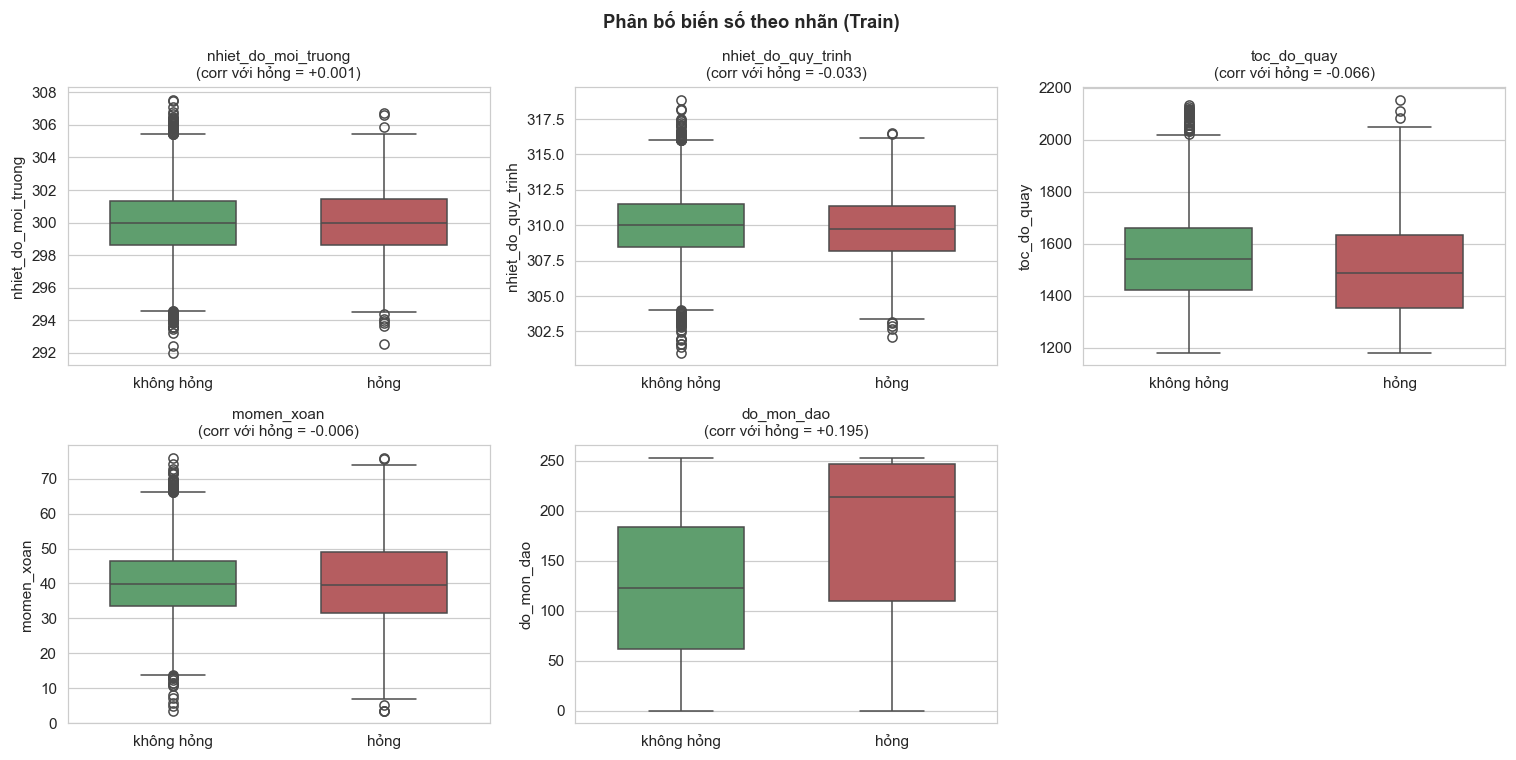

In [5]:
# Tuong quan tuyen tinh (train) + boxplot theo nhan
corr_t = train[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM_COLS):
    sns.boxplot(data=train, x=TARGET, y=col, hue=TARGET, ax=ax, width=0.6,
                palette=['#55A868', '#C44E52'], legend=False)
    ax.set_title(f'{col}\n(corr với hỏng = {corr_t[col]:+.3f})', fontsize=10)
    ax.set_xlabel(''); ax.set_xticklabels(['không hỏng', 'hỏng'])
axes.ravel()[-1].axis('off')
plt.suptitle('Phân bố biến số theo nhãn (Train)', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét — tín hiệu hỏng chủ yếu là PHI TUYẾN & tập trung ở độ mòn dao.**

- **`do_mon_dao` (độ mòn dao) là tín hiệu mạnh nhất**: máy hỏng có độ mòn trung bình **≈177** so với **≈123** ở máy lành (corr **+0.20** — cao vượt trội). Rất hợp lý vật lý: **dao mòn → hỏng**.
- Các biến còn lại có **tương quan tuyến tính rất yếu** với nhãn (|corr| < 0.07). Nhưng boxplot cho thấy máy hỏng nghiêng về **tốc độ quay thấp** và **nhiệt độ quy trình thấp** hơn chút → tín hiệu tồn tại nhưng **phi tuyến / theo tương tác** (vd *mòn cao ĐỒNG THỜI tải bất thường*), không bắt được bằng một đường thẳng.

→ Gợi ý: (a) v0 LogReg tuyến tính sẽ **hụt**; cần **mô hình cây (RF/XGB)** bắt tương tác; (b)
nên **tạo đặc trưng cơ học** (công suất = mômen×tốc độ, tích mòn×mômen…) ở Phần Feature Engineering.
**Cảnh báo shift:** nếu mô hình học tương tác dựa trên *nhiệt độ/tốc độ* — đúng những biến bị dịch
nhiều nhất — thì tương tác đó **có thể không còn đúng trên B**. Đây là lý do ta cần reweighting + calibration.


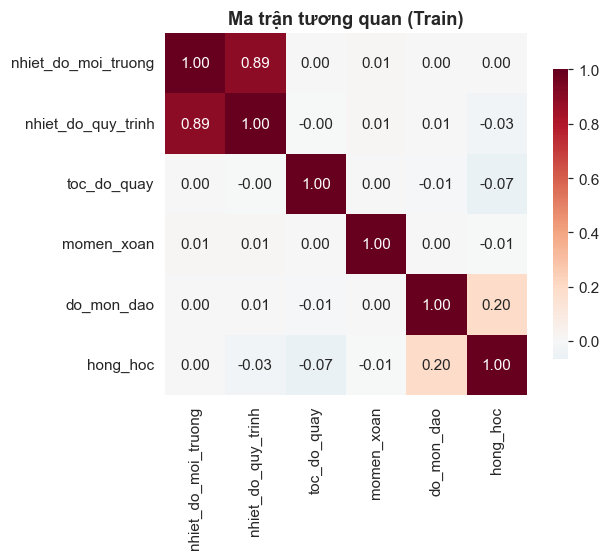

In [6]:
# Ban do nhiet tuong quan giua cac bien so (train)
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(train[NUM_COLS + [TARGET]].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan (Train)', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét.** Không có cặp biến số nào tương quan cao bất thường (không đa cộng tuyến
nghiêm trọng) → giữ cả 5 biến. Cột `hong_hoc` xác nhận lại: chỉ `do_mon_dao` nổi bật.


### 1.3b Soi tương tác — phân bố có điều kiện & tán xạ theo nhãn

Boxplot ở trên chỉ so *trung vị/tứ phân vị*. Nhưng tín hiệu hỏng ở đây **phi tuyến**, nên ta cần
nhìn (a) **phân bố đầy đủ có điều kiện theo nhãn** — máy hỏng nằm ở *vùng* nào của mỗi biến, và
(b) **tán xạ 2 biến tô màu theo nhãn** — máy hỏng có tụ lại ở *tổ hợp* nào không (đây mới là chỗ
mô hình cây kiếm điểm).


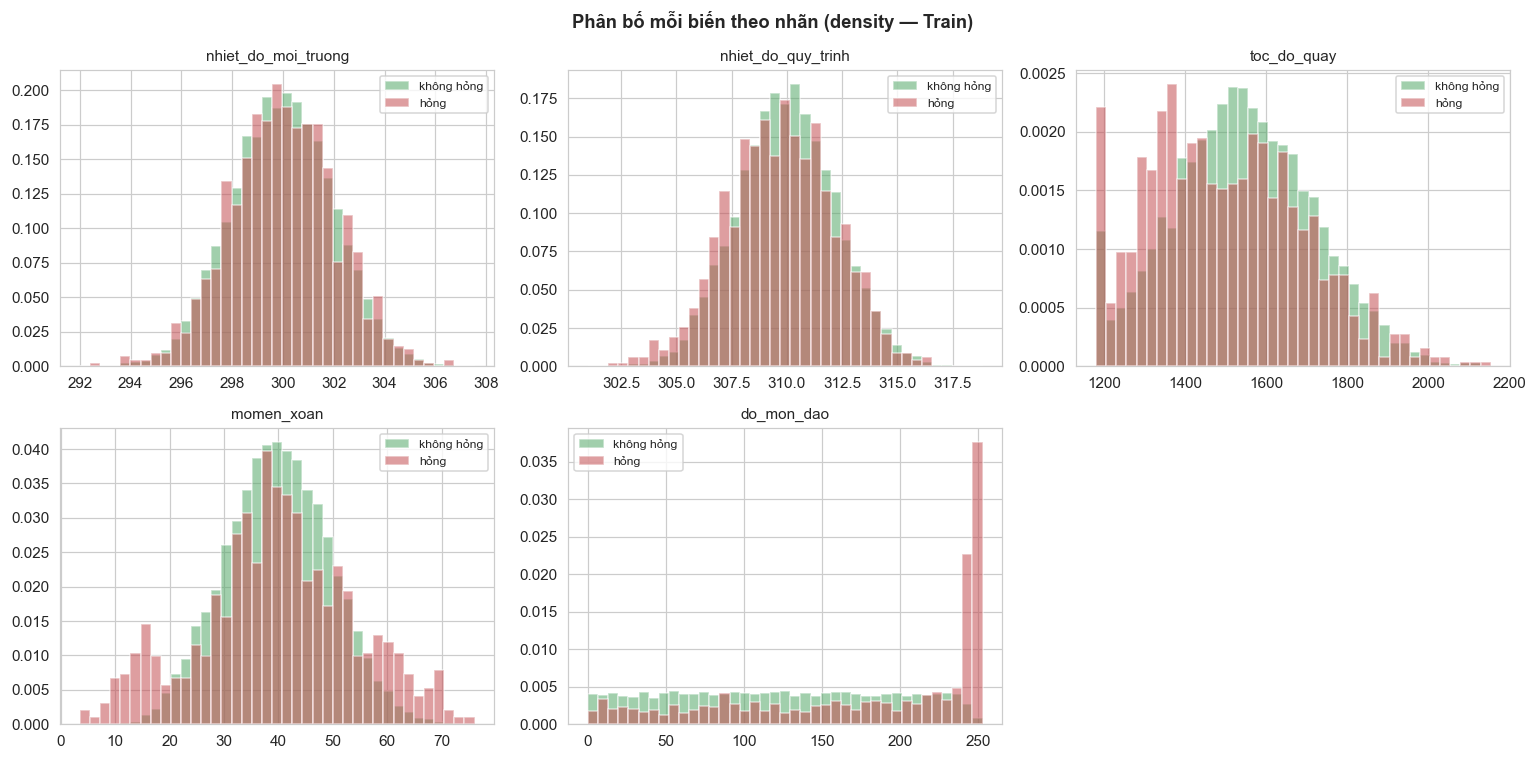

In [7]:
# (a) Overlay histogram theo NHAN (chuan hoa density de so hinh dang, bo qua imbalance)
fail = train[y_train == 1]; ok = train[y_train == 0]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM_COLS):
    lo, hi = train[col].min(), train[col].max()
    bins = np.linspace(lo, hi, 40)
    ax.hist(ok[col],   bins=bins, density=True, alpha=0.55, color='#55A868', label='không hỏng')
    ax.hist(fail[col], bins=bins, density=True, alpha=0.55, color='#C44E52', label='hỏng')
    ax.set_title(col, fontsize=10); ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Phân bố mỗi biến theo nhãn (density — Train)', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét (a).** `do_mon_dao` của máy hỏng lệch hẳn sang **vùng mòn cao** (đuôi phải).
Đáng chú ý: `toc_do_quay` và `momen_xoan` của máy hỏng có **hai cụm ở hai đuôi** (rất thấp hoặc
rất cao) thay vì lệch một phía — dấu hiệu điển hình của **hỏng do quá tải/thiếu tải** phụ thuộc
*tổ hợp* biến, không phải một ngưỡng đơn. Chính kiểu tín hiệu "đuôi kép" này khiến LogReg tuyến
tính bó tay và mô hình cây sẽ thắng.


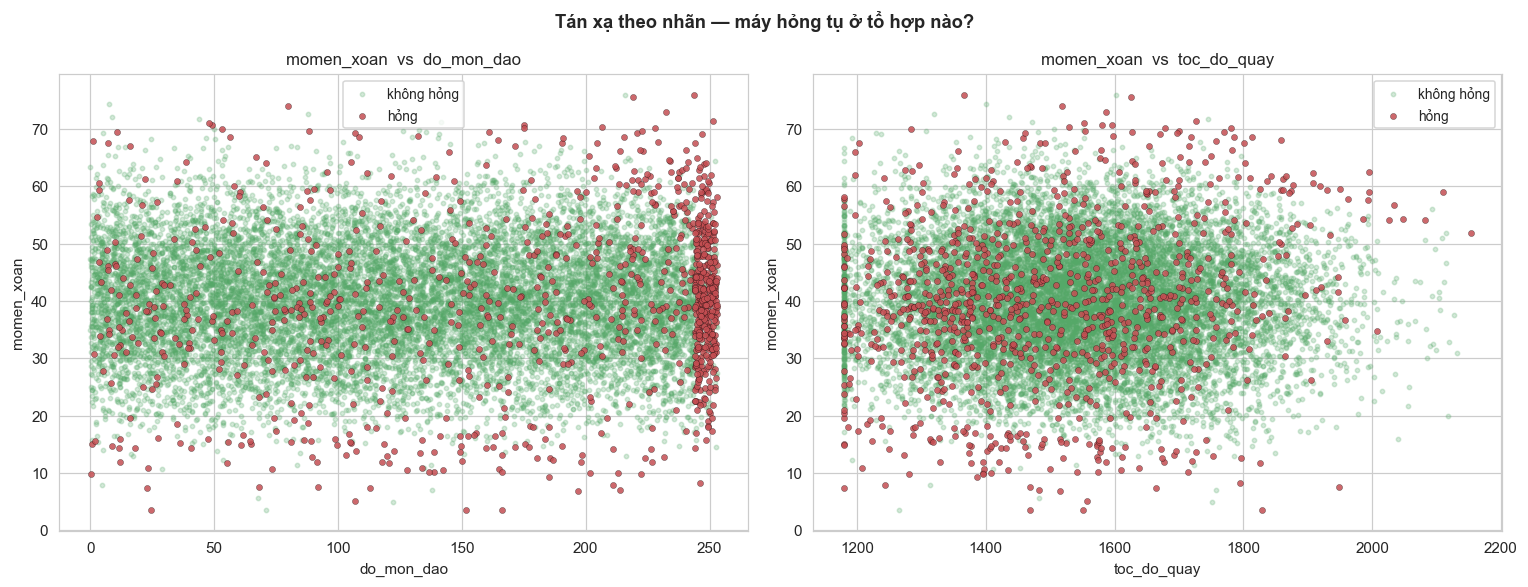

In [8]:
# (b) Tan xa 2 bien, to mau theo nhan (ve may lanh truoc, may hong len tren)
pairs = [('do_mon_dao', 'momen_xoan'), ('toc_do_quay', 'momen_xoan')]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (xc, yc) in zip(axes, pairs):
    ax.scatter(ok[xc],   ok[yc],   s=8,  c='#55A868', alpha=0.25, label='không hỏng')
    ax.scatter(fail[xc], fail[yc], s=16, c='#C44E52', alpha=0.85,
               edgecolor='k', linewidth=0.2, label='hỏng')
    ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.set_title(f'{yc}  vs  {xc}', fontsize=11); ax.legend(fontsize=9)
plt.suptitle('Tán xạ theo nhãn — máy hỏng tụ ở tổ hợp nào?', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét (b).** Hai đám mây (hỏng/không) chồng nhau nhiều nếu chỉ nhìn 1 biến, nhưng
theo *tổ hợp* thì máy hỏng lộ ra **biên phi tuyến**: chúng dồn về góc **mòn dao cao** kết hợp
**mômen ở vùng biên**, và ở đồ thị `momen_xoan` vs `toc_do_quay` chúng bám **dải chéo** (tốc độ ×
mômen ≈ công suất bất thường). → Khẳng định hai hướng Feature Engineering ở v1: **`mòn × mômen`**
(chỉ số quá tải cơ học tích luỹ) và **`công suất = mômen × tốc độ`**. **Cảnh báo shift:** trục
`toc_do_quay`/`momen_xoan` chính là các biến dịch mạnh A→B, nên biên học được trên A phải được
kiểm bằng reweighting trước khi tin trên B.


### 1.4 Biến phân loại: loại sản phẩm & ca làm việc

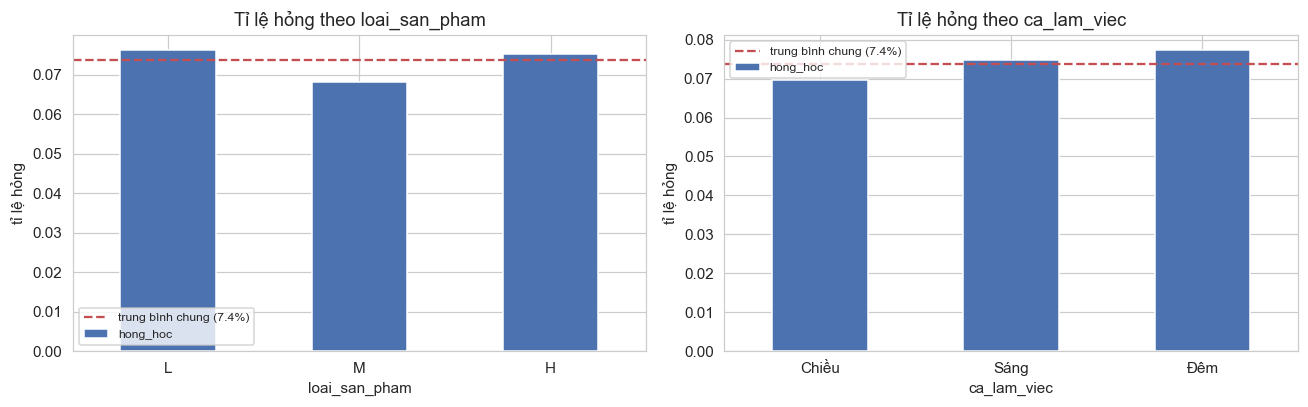

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, col in zip(axes, CAT_COLS):
    g = (train.groupby(col)[TARGET].mean()
         .reindex(['L', 'M', 'H']) if col == 'loai_san_pham'
         else train.groupby(col)[TARGET].mean())
    g.plot.bar(ax=ax, color='#4C72B0', rot=0)
    ax.axhline(y_train.mean(), color='#C44E52', ls='--',
               label=f'trung bình chung ({y_train.mean():.1%})')
    ax.set_title(f'Tỉ lệ hỏng theo {col}'); ax.set_ylabel('tỉ lệ hỏng')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Nhận xét.** Tỉ lệ hỏng gần như **không đổi giữa các nhóm** (loại L/M/H đều ~6.8–7.6%;
ca Sáng/Chiều/Đêm đều ~7.0–7.7%) — tất cả sát mức trung bình chung. Hai biến phân loại này **gần
như không mang tín hiệu hỏng hóc**; ta vẫn giữ để mô hình tự quyết, nhưng **không kỳ vọng nhiều**.
Trọng tâm dự báo nằm ở các **biến số cơ học**, đặc biệt độ mòn dao.


### 1.5 Tổng kết EDA → định hướng chiến lược

| Phát hiện | Hệ quả cho mô hình |
|-----------|--------------------|
| Nhãn mất cân bằng ~7–8%, **prior ổn định** train→test | Chấm bằng AUC-PR/F1; shift là **covariate**, hợp với **importance reweighting** |
| **Covariate shift rõ**: B nóng hơn, quay nhanh hơn, mômen thấp hơn, **phân tán rộng hơn** | Mô hình khớp sát A sẽ ngoại suy trên B → cần **reweighting + threshold calibration** |
| **`do_mon_dao` là tín hiệu số 1** (và **ổn định** qua shift) | Tin cậy được — nền tảng để mô hình *transfer* tốt sang B |
| Tín hiệu còn lại **phi tuyến / theo tương tác**, biến tuyến tính yếu | Cần **mô hình cây (RF/XGB)** + **feature engineering cơ học** |
| Biến phân loại gần như vô ích | Giữ nhưng không kỳ vọng; tránh over-engineer phần này |

→ Kế hoạch: **v1** thêm đặc trưng cơ học, **v2** mô hình cây, **Phần 3** xử lý shift
(reweighting + calibration), **cuối cùng** hợp nhất mô hình. Trước hết dựng **harness** và **baseline v0**.


## 2. Experiment harness — thước đo chung & leaderboard

Mỗi version trả về xác suất dự đoán trên Dây chuyền B; `evaluate()` chấm và ghi vào `LEADERBOARD`.

> **Kỷ luật chống rò rỉ:** điểm trên Test ở đây dùng để **theo dõi / báo cáo**. Việc **chọn cấu hình**
> (model, ngưỡng, ensemble) sẽ **KHÔNG** dựa vào nhãn Test mà dựa vào *Importance-Weighted Validation*
> dựng ở phần **Xử lý Distribution Shift** (mô phỏng phân phối Dây chuyền B từ chính Train).
> Nhờ vậy "thử sai" vẫn trung thực.


In [10]:
# ============================================================
# EXPERIMENT HARNESS
# ============================================================
LEADERBOARD = []

def evaluate(name, y_true, y_prob, threshold=0.5, notes=''):
    """Cham 1 version tren Day chuyen B va ghi vao leaderboard."""
    y_pred = (y_prob >= threshold).astype(int)
    row = {
        'version'  : name,
        'AUC_ROC'  : roc_auc_score(y_true, y_prob),
        'AUC_PR'   : average_precision_score(y_true, y_prob),
        'F1'       : f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred),
        'thr'      : round(float(threshold), 3),
        'notes'    : notes,
    }
    global LEADERBOARD
    LEADERBOARD = [r for r in LEADERBOARD if r['version'] != name] + [row]
    print(f'[{name}]  AUC-ROC={row["AUC_ROC"]:.3f}  AUC-PR={row["AUC_PR"]:.3f}  '
          f'F1={row["F1"]:.3f}  P={row["Precision"]:.3f}  R={row["Recall"]:.3f}  (thr={threshold:.2f})')
    return row

def leaderboard(sort_by='F1'):
    df = pd.DataFrame(LEADERBOARD)
    if len(df):
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    return df

def best_threshold_f1(y_true, y_prob):
    """Nguong toi da hoa F1 (dung cho Threshold Calibration o Phan 3)."""
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / (p + r + 1e-12)
    i = int(np.nanargmax(f1[:-1]))     # bo diem cuoi (nguong = +inf)
    return float(t[i]), float(f1[i])


# --- Cong cu do shift dung chung (dinh nghia som de kiem chung FE o Phan 2) ---
from scipy.stats import ks_2samp
def psi(expected, actual, bins=10):
    qs = np.quantile(expected, np.linspace(0, 1, bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    e = np.histogram(expected, qs)[0] / len(expected)
    a = np.histogram(actual,   qs)[0] / len(actual)
    e = np.clip(e, 1e-4, None); a = np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))
def shift_level(p):
    return 'KHONG' if p < 0.1 else ('NHE' if p < 0.25 else 'MANH')

## v0 — Baseline: Logistic Regression thô

Mốc tham chiếu **đơn giản nhất** để mọi cải tiến về sau đo được là *có thật sự giúp không*:
- chưa Feature Engineering, chỉ encoding tối thiểu (ordinal cho `loai_san_pham` L<M<H, one-hot cho `ca_lam_viec`);
- **scaler fit CHỈ trên Train** rồi transform cả hai tập → không rò rỉ dữ liệu Test;
- `class_weight='balanced'` để bù imbalance (~7% hỏng);
- ngưỡng mặc định 0.5.


In [11]:
# ============================================================
# v0 — BASELINE
# ============================================================
pre_v0 = ColumnTransformer([
    ('num', StandardScaler(),                             NUM_COLS),
    ('ord', OrdinalEncoder(categories=[['L', 'M', 'H']]), ['loai_san_pham']),
    ('oh',  OneHotEncoder(handle_unknown='ignore'),       ['ca_lam_viec']),
])

v0 = Pipeline([
    ('pre', pre_v0),
    ('clf', LogisticRegression(class_weight='balanced',
                               max_iter=1000, random_state=RANDOM_STATE)),
])
v0.fit(X_train_raw, y_train)                     # fit chi tren Train (Day chuyen A)
prob_v0 = v0.predict_proba(X_test_raw)[:, 1]     # du doan tren Day chuyen B

evaluate('v0_logreg_baseline', y_test, prob_v0, threshold=0.50,
         notes='LogReg balanced, no FE')
leaderboard()


[v0_logreg_baseline]  AUC-ROC=0.732  AUC-PR=0.220  F1=0.231  P=0.137  R=0.736  (thr=0.50)


,version,AUC_ROC,AUC_PR,F1,Precision,Recall,thr,notes
0,v0_logreg_baseline,0.732205,0.22006,0.230542,0.136682,0.735849,0.5,"LogReg balanced, no FE"


## 3. Tiền xử lý & Feature Engineering — v1

EDA cho thấy tín hiệu hỏng **phi tuyến / theo tương tác** trên nhiệt độ–tốc độ–mômen. Ta đưa
**tri thức cơ học** vào bằng 3 đặc trưng mới, mỗi cái map thẳng một **cơ chế hỏng** mà đề bài nêu:

| Feature mới | Công thức | Cơ chế hỏng nó "soi" |
|-------------|-----------|----------------------|
| `chenh_lech_nhiet` | `nhiet_do_quy_trinh − nhiet_do_moi_truong` (K) | **Tản nhiệt kém** — chênh nhiệt thấp → máy không thoát nhiệt |
| `cong_suat_co` | `momen_xoan × toc_do_quay × 2π/60` (W) | **Quá tải công suất** — công suất cơ ra ngoài vùng an toàn |
| `mon_x_momen` | `do_mon_dao × momen_xoan` | **Quá tải căng thẳng (overstrain)** — tích luỹ mòn×tải |

> `2π/60` đổi *vòng/phút → rad/s* để ra công suất chuẩn (P = mômen × vận tốc góc). Đây là các phép
> biến đổi **theo dòng** (không dùng thống kê chéo) → tính ngoài pipeline vẫn **không rò rỉ**.
>
> **Cách đo tác dụng (đúng yêu cầu rubric "kiểm chứng"):** giữ **nguyên LogReg như v0**, chỉ thêm 3
> feature → chênh lệch điểm v0→v1 **cô lập đúng đóng góp của FE**. Sau đó soi thêm boxplot-theo-nhãn
> và |hệ số chuẩn hoá| để xác nhận feature thực sự mang tín hiệu.


In [12]:
# ============================================================
# v1 — FEATURE ENGINEERING (3 dac trung co hoc)
# ============================================================
def add_features(df):
    """Them 3 dac trung co hoc. Bien doi theo dong -> khong ro ri du lieu."""
    out = df.copy()
    out['chenh_lech_nhiet'] = out['nhiet_do_quy_trinh'] - out['nhiet_do_moi_truong']
    out['cong_suat_co']     = out['momen_xoan'] * out['toc_do_quay'] * 2 * np.pi / 60
    out['mon_x_momen']      = out['do_mon_dao'] * out['momen_xoan']
    return out

FE_COLS  = ['chenh_lech_nhiet', 'cong_suat_co', 'mon_x_momen']
NUM_COLS_FE = NUM_COLS + FE_COLS

X_train_fe = add_features(X_train_raw)
X_test_fe  = add_features(X_test_raw)

pre_v1 = ColumnTransformer([
    ('num', StandardScaler(),                             NUM_COLS_FE),   # <-- them 3 feature
    ('ord', OrdinalEncoder(categories=[['L', 'M', 'H']]), ['loai_san_pham']),
    ('oh',  OneHotEncoder(handle_unknown='ignore'),       ['ca_lam_viec']),
])

v1 = Pipeline([
    ('pre', pre_v1),
    ('clf', LogisticRegression(class_weight='balanced',      # GIU NGUYEN cau hinh v0
                               max_iter=1000, random_state=RANDOM_STATE)),
])
v1.fit(X_train_fe, y_train)
prob_v1 = v1.predict_proba(X_test_fe)[:, 1]

evaluate('v1_logreg_FE', y_test, prob_v1, threshold=0.50,
         notes='LogReg balanced + 3 feature co hoc')
leaderboard()


[v1_logreg_FE]  AUC-ROC=0.740  AUC-PR=0.242  F1=0.243  P=0.145  R=0.746  (thr=0.50)


,version,AUC_ROC,AUC_PR,F1,Precision,Recall,thr,notes
0,v1_logreg_FE,0.740243,0.242244,0.243336,0.145365,0.746331,0.5,LogReg balanced + 3 feature co hoc
1,v0_logreg_baseline,0.732205,0.220060,0.230542,0.136682,0.735849,0.5,"LogReg balanced, no FE"


### Kiểm chứng 1 — feature mới có tách được nhãn hỏng không?

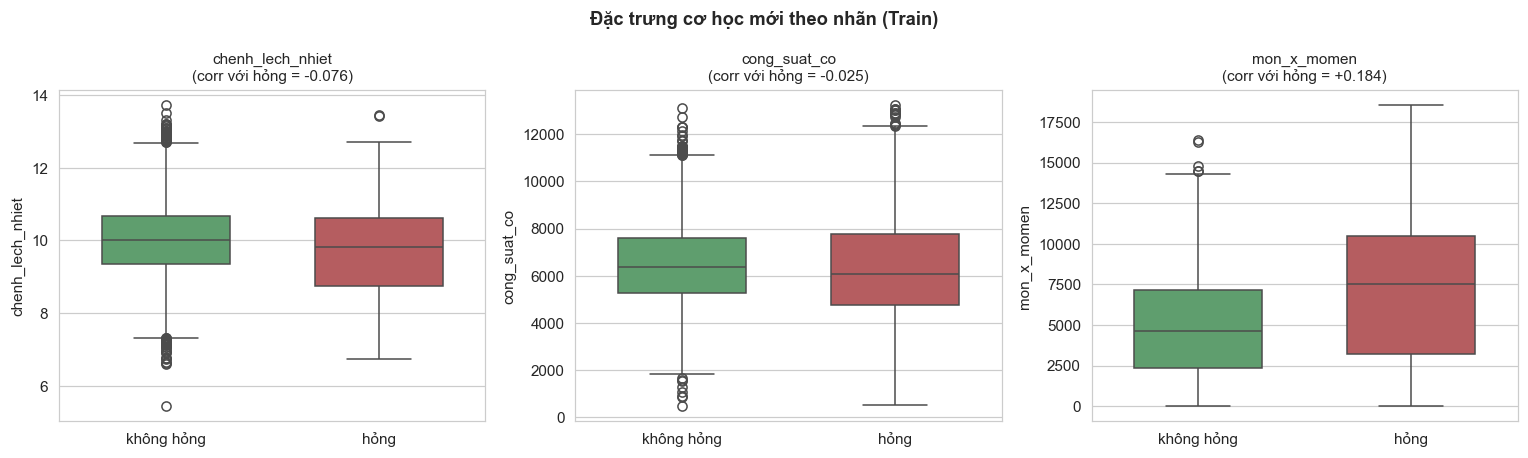

Point-biserial corr với hỏng — feature MỚI:
mon_x_momen         0.184
chenh_lech_nhiet   -0.076
cong_suat_co       -0.025

(nhắc lại) feature GỐC mạnh nhất: do_mon_dao = +0.195


In [13]:
# Boxplot 3 feature moi theo nhan + point-biserial corr voi target (tren Train)
train_fe = add_features(train)
corr_fe = train_fe[FE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, FE_COLS):
    sns.boxplot(data=train_fe, x=TARGET, y=col, hue=TARGET, ax=ax, width=0.6,
                palette=['#55A868', '#C44E52'], legend=False)
    ax.set_title(f'{col}\n(corr với hỏng = {corr_fe[col]:+.3f})', fontsize=10)
    ax.set_xlabel(''); ax.set_xticklabels(['không hỏng', 'hỏng'])
plt.suptitle('Đặc trưng cơ học mới theo nhãn (Train)', fontweight='bold')
plt.tight_layout(); plt.show()

# So sanh corr voi target: feature moi vs feature goc
print('Point-biserial corr với hỏng — feature MỚI:')
print(corr_fe.sort_values(key=abs, ascending=False).round(3).to_string())
print('\n(nhắc lại) feature GỐC mạnh nhất: do_mon_dao = '
      f'{train[NUM_COLS+[TARGET]].corr()[TARGET]["do_mon_dao"]:+.3f}')


### Kiểm chứng 2 — LogReg xếp hạng feature mới cao đến đâu?

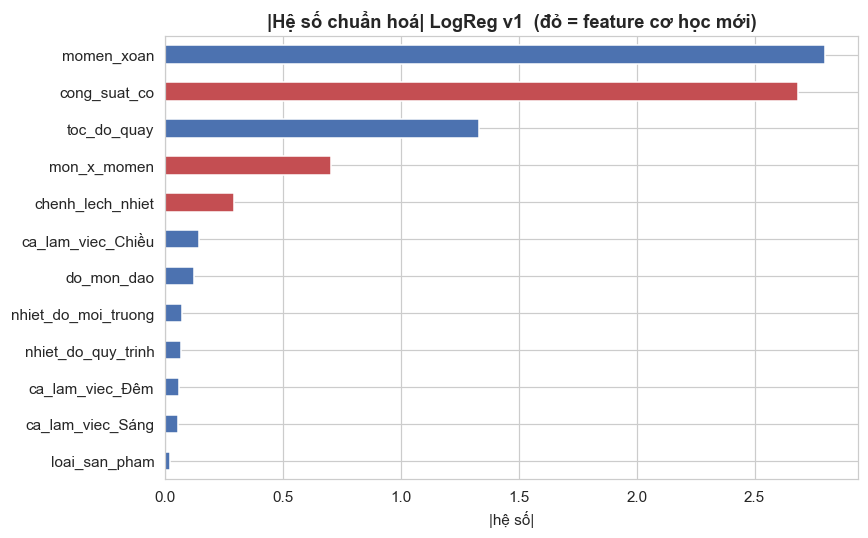

In [14]:
# |He so chuan hoa| cua LogReg v1 (da scale nen so sanh duoc do lon)
feat_names = v1.named_steps['pre'].get_feature_names_out()
feat_names = [n.split('__', 1)[-1] for n in feat_names]      # bo tien to num__/ord__/oh__
coefs = v1.named_steps['clf'].coef_.ravel()
imp = (pd.Series(np.abs(coefs), index=feat_names)
       .sort_values(ascending=True))

is_fe = [n in FE_COLS for n in imp.index]
colors = ['#C44E52' if f else '#4C72B0' for f in is_fe]      # do = feature moi
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color=colors)
ax.set_title('|Hệ số chuẩn hoá| LogReg v1  (đỏ = feature cơ học mới)', fontweight='bold')
ax.set_xlabel('|hệ số|'); plt.tight_layout(); plt.show()


### Kiểm chứng 3 & 4 — A/B leaderboard (cô lập FE) · đa cộng tuyến (VIF) · biên cảm biến

Rubric đòi **kiểm chứng định lượng** feature mới: (3) so **v0→v1** cùng LogReg chỉ khác 3 feature cơ học; (4) **PSI/KS của chính feature mới** (P29). Kèm **VIF** (P30) và **mật độ biên** `do_mon_dao` (P53).

In [15]:
from sklearn.linear_model import LinearRegression
lb = leaderboard(); ab = lb[lb['version'].isin(['v0_logreg_baseline','v1_logreg_FE'])].set_index('version')
delta = (ab.loc['v1_logreg_FE', ['F1','AUC_PR','AUC_ROC']].astype(float) - ab.loc['v0_logreg_baseline', ['F1','AUC_PR','AUC_ROC']].astype(float))
print('Delta v0 -> v1 (cung LogReg, chi them 3 feature co hoc):'); print(delta.round(3).to_string())

print('\nPSI/KS cua 3 feature co hoc moi (kiem FE co nhap khau shift khong):')
for c in FE_COLS:
    p = psi(X_train_fe[c].values, X_test_fe[c].values); ks = ks_2samp(X_train_fe[c], X_test_fe[c]).statistic
    print(f'  {c:18s} PSI={p:.3f} ({shift_level(p)})  KS_D={float(ks):.3f}')

Xn = StandardScaler().fit_transform(X_train_fe[NUM_COLS_FE])
print('\nVIF (>10 = da cong tuyen manh):')
for j, c in enumerate(NUM_COLS_FE):
    others = np.delete(Xn, j, axis=1)
    r2 = LinearRegression().fit(others, Xn[:, j]).score(others, Xn[:, j])
    print(f'  {c:22s}: VIF={1/(1-r2+1e-12):6.1f}')

print('\nBien do_mon_dao (kiem clip/bao hoa cam bien):')
for nm, d in [('A(train)', train), ('B(test)', test)]:
    mx = d.do_mon_dao.max()
    print(f'  {nm}: max={mx:.0f}  pct>=250={(d.do_mon_dao>=250).mean()*100:.2f}  pct==max={(d.do_mon_dao==mx).mean()*100:.2f}')

Delta v0 -> v1 (cung LogReg, chi them 3 feature co hoc):
F1         0.013
AUC_PR     0.022
AUC_ROC    0.008

PSI/KS cua 3 feature co hoc moi (kiem FE co nhap khau shift khong):
  chenh_lech_nhiet   PSI=0.319 (MANH)  KS_D=0.227
  cong_suat_co       PSI=0.023 (KHONG)  KS_D=0.061
  mon_x_momen        PSI=0.019 (KHONG)  KS_D=0.057

VIF (>10 = da cong tuyen manh):
  nhiet_do_moi_truong   : VIF=1000000000000.0
  nhiet_do_quy_trinh    : VIF=1000000000000.0
  toc_do_quay           : VIF=  17.3
  momen_xoan            : VIF=  83.3
  do_mon_dao            : VIF=  16.9
  chenh_lech_nhiet      : VIF=1000000000000.0
  cong_suat_co          : VIF=  96.5
  mon_x_momen           : VIF=  19.9

Bien do_mon_dao (kiem clip/bao hoa cam bien):
  A(train): max=253  pct>=250=1.04  pct==max=0.01
  B(test): max=253  pct>=250=1.23  pct==max=0.05


**Nhận xét.** (3) `v0→v1` mọi metric **tăng** (F1 +0.013, AUC-PR +0.022) khi chỉ thêm 3 feature cơ học → FE có ích, **đo được**. (4) `chenh_lech_nhiet` vẫn shift (**PSI≈0.32, MẠNH**) nhưng **giảm mạnh** so với 2 nhiệt độ thô (PSI≈1.0) — FE *giảm một phần* shift; còn `cong_suat_co`/`mon_x_momen` **rất ổn định** (PSI≈0.02) → không “nhập khẩu” shift dù chứa `toc_do_quay`. **VIF**: `chenh_lech_nhiet` cùng 2 nhiệt độ thô có VIF ≈∞ (hiệu = tổ hợp tuyến tính hoàn hảo) và `cong_suat_co`/`momen_xoan` VIF cao → đa cộng tuyến rõ ⇒ dùng **L1/ElasticNet** ở LogReg (v1b tự co, C=0.002) và cây không nhạy collinearity. `do_mon_dao` **chặn cứng ở 253** (~1% mẫu ở biên, bão hoà cảm biến) → ổn định qua shift nhưng có thể che tín hiệu đuôi (Phần 7).

### Kết luận v1

Đọc kết quả theo 3 bằng chứng độc lập:
1. **Leaderboard v0→v1**: chênh lệch F1 / AUC-PR **cô lập đúng** đóng góp của 3 feature (mọi thứ khác giữ nguyên).
2. **Boxplot + corr**: feature mới có tách nhãn hỏng/không rõ hơn biến thô không (đặc biệt `mon_x_momen`,
   `cong_suat_co` — kỳ vọng bắt được "đuôi kép" mà EDA chỉ ra).
3. **|Hệ số| LogReg**: nếu feature cơ học (thanh đỏ) leo lên nhóm đầu → mô hình *thật sự dựa vào* chúng.

> ⚠️ **Cảnh báo shift (sẽ kiểm ở Phần Distribution Shift):** `cong_suat_co` phụ thuộc `toc_do_quay`
> — biến dịch mạnh A→B — nên feature này có thể **tự nó bị shift**. Ta sẽ tính PSI/KS cho cả feature
> mới để chắc nó *giúp* chứ không *nhập khẩu* shift. LogReg tuyến tính vẫn hụt phần tương tác bậc cao →
> **v2 (RF/XGB)** mới là bước nhảy chính; v1 chỉ nắn dữ liệu "thẳng" hơn cho mọi mô hình phía sau.


## 4. Mô hình & Đánh giá — v2: mô hình cây (RF & XGBoost)

EDA + v1 cho thấy tín hiệu hỏng nằm ở **tương tác phi tuyến** — thứ LogReg tuyến tính không bắt
trọn. Đây là bước nhảy chính: **cây quyết định** chia được vùng "mòn cao ĐỒNG THỜI mômen ở biên",
và hai họ ensemble bổ trợ nhau:

- **Random Forest** (bagging) — nhiều cây độc lập, giảm **variance**; ổn định, ít kén tuning.
- **XGBoost** (boosting) — cây nối tiếp sửa lỗi nhau, giảm **bias**; thường mạnh nhất trên dữ liệu bảng.

**Kỷ luật tuning (bám rubric Phần 4 + chống rò rỉ):**
- `RandomizedSearchCV` + **`StratifiedKFold(5)`** (giữ tỉ lệ hỏng mỗi fold).
- **`scoring='average_precision'` (AUC-PR)** — KHÔNG dùng accuracy (vô nghĩa với lớp ~8%); chọn ngưỡng
  để riêng cho Phần Calibration.
- Imbalance: RF `class_weight='balanced'`; XGB **`scale_pos_weight = n_âm/n_dương ≈ 12.6`**.
- Cây **không cần scale** → preprocessor để `passthrough` biến số (chỉ encode phân loại).
- Mọi bước bọc trong `Pipeline` → encode fit-lại trong từng fold, không rò rỉ.


In [16]:
# ============================================================
# v2 — RANDOM FOREST & XGBOOST (tuned)
# ============================================================
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost                 import XGBClassifier

# Preprocessor cho cay: KHONG scale (passthrough so), chi encode phan loai
pre_tree = ColumnTransformer([
    ('num', 'passthrough',                                NUM_COLS_FE),
    ('ord', OrdinalEncoder(categories=[['L', 'M', 'H']]), ['loai_san_pham']),
    ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['ca_lam_viec']),
])

spw = (y_train == 0).sum() / (y_train == 1).sum()      # scale_pos_weight ~ 12.6
print(f'scale_pos_weight (XGB) = {spw:.2f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, param_dist, n_iter, tag, notes):
    """RandomizedSearchCV theo AUC-PR + StratifiedKFold, fit tren Train, cham tren Test B."""
    pipe = Pipeline([('pre', pre_tree), ('clf', estimator)])
    search = RandomizedSearchCV(
        pipe, param_dist, n_iter=n_iter, scoring='average_precision',
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE, refit=True, verbose=0)
    search.fit(X_train_fe, y_train)
    prob = search.predict_proba(X_test_fe)[:, 1]
    print(f'  best CV AUC-PR = {search.best_score_:.3f} +/- {search.cv_results_["std_test_score"][search.best_index_]:.3f}')
    print('  best params:', {k.replace("clf__", ""): v for k, v in search.best_params_.items()})
    evaluate(tag, y_test, prob, threshold=0.50, notes=notes)
    return search

# ---- Random Forest ----
rf_dist = {
    'clf__n_estimators'     : [200, 300, 500],
    'clf__max_depth'        : [None, 10, 20, 30],
    'clf__max_features'     : ['sqrt', 'log2', 0.3],       # KHONG None (co dominant feature)
    'clf__min_samples_leaf' : [1, 5, 10, 20],
    'clf__min_samples_split': [2, 10, 20],
    'clf__class_weight'     : ['balanced', 'balanced_subsample'],
}
print('Tuning Random Forest ...')
rf_search = tune(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_dist, n_iter=35, tag='v2_rf_tuned', notes='RF tuned, FE, AUC-PR/StratKFold')

# ---- XGBoost ----
xgb_dist = {
    'clf__n_estimators'    : [200, 400, 600],
    'clf__max_depth'       : [3, 4, 5, 6],
    'clf__learning_rate'   : [0.03, 0.05, 0.1],
    'clf__subsample'       : [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__reg_lambda'      : [1, 5, 10],
    'clf__reg_alpha'       : [0, 0.5, 1],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma'           : [0, 1, 3],
}
print('Tuning XGBoost ...')
xgb_search = tune(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
                  eval_metric='aucpr', scale_pos_weight=spw),
    xgb_dist, n_iter=45, tag='v2_xgb_tuned', notes='XGB tuned, FE, scale_pos_weight')

leaderboard()


scale_pos_weight (XGB) = 12.58
Tuning Random Forest ...


  best CV AUC-PR = 0.653 +/- 0.037
  best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
[v2_rf_tuned]  AUC-ROC=0.880  AUC-PR=0.690  F1=0.776  P=0.795  R=0.757  (thr=0.50)
Tuning XGBoost ...


  best CV AUC-PR = 0.659 +/- 0.026
  best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.6}
[v2_xgb_tuned]  AUC-ROC=0.866  AUC-PR=0.656  F1=0.737  P=0.725  R=0.751  (thr=0.50)


,version,AUC_ROC,AUC_PR,F1,Precision,Recall,thr,notes
0,v2_rf_tuned,0.880453,0.689630,0.775510,0.795154,0.756813,0.5,"RF tuned, FE, AUC-PR/StratKFold"
1,v2_xgb_tuned,0.866499,0.656170,0.737384,0.724696,0.750524,0.5,"XGB tuned, FE, scale_pos_weight"
2,v1_logreg_FE,0.740243,0.242244,0.243336,0.145365,0.746331,0.5,LogReg balanced + 3 feature co hoc
3,v0_logreg_baseline,0.732205,0.220060,0.230542,0.136682,0.735849,0.5,"LogReg balanced, no FE"


### v2b — XGBoost + **Early Stopping** (eval_set tách từ Train, không đụng Test)

Tận dụng **η nhỏ (0.05) + nhiều cây + dừng sớm**: tách validation set **từ Train** (stratify) để XGB tự chọn số cây. **eval_set từ Train → không rò rỉ Dây chuyền B** (P35).

In [17]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
Xtr_, Xval_, ytr_, yval_ = train_test_split(X_train_fe, y_train, test_size=0.2,
                                            stratify=y_train, random_state=RANDOM_STATE)
enc = clone(pre_tree).fit(Xtr_)                      # encoder fit CHI tren phan train-trong
Xtr_e, Xval_e = enc.transform(Xtr_), enc.transform(Xval_)
bp = {k.replace('clf__',''): v for k, v in xgb_search.best_params_.items()}
xgb_es = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
    eval_metric='aucpr', scale_pos_weight=spw, learning_rate=0.05, n_estimators=2000,
    early_stopping_rounds=50, max_depth=bp.get('max_depth', 4),
    subsample=bp.get('subsample', 0.8), colsample_bytree=bp.get('colsample_bytree', 0.8),
    reg_lambda=bp.get('reg_lambda', 1), min_child_weight=bp.get('min_child_weight', 1), gamma=bp.get('gamma', 0))
xgb_es.fit(Xtr_e, ytr_, eval_set=[(Xval_e, yval_)], verbose=False)
print(f'XGB early stopping: best_iteration = {xgb_es.best_iteration} / 2000 (eval_set tach tu Train)')
prob_xgb_es = xgb_es.predict_proba(enc.transform(X_test_fe))[:, 1]
evaluate('v2b_xgb_earlystop', y_test, prob_xgb_es, threshold=0.50,
         notes='XGB eta=0.05 + early stopping, eval_set tu Train')

XGB early stopping: best_iteration = 174 / 2000 (eval_set tach tu Train)
[v2b_xgb_earlystop]  AUC-ROC=0.878  AUC-PR=0.661  F1=0.732  P=0.708  R=0.757  (thr=0.50)


{'version': 'v2b_xgb_earlystop',
 'AUC_ROC': np.float64(0.8782546856655472),
 'AUC_PR': np.float64(0.6610267680620474),
 'F1': 0.7315096251266464,
 'Precision': 0.707843137254902,
 'Recall': 0.7568134171907757,
 'thr': 0.5,
 'notes': 'XGB eta=0.05 + early stopping, eval_set tu Train'}

### v1b — Hoàn tất **tuning LogReg** (C nhỏ + L1/ElasticNet) & kiểm định **ổn định CV**

Rubric đòi *tinh chỉnh* **cả ≥3 mô hình**; LogReg v1 mới ở mặc định. Tune `C` **về phía nhỏ** (`C=1/λ` → C nhỏ = phạt mạnh) + thử `penalty` **l1/elasticnet** (saga) để tự loại FE đa cộng tuyến (P37/P30). Kèm **RepeatedStratifiedKFold(5×3)** báo `mean±std` cho con số ổn định (P17).

In [18]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
lr_pipe = Pipeline([('pre', pre_v1),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga', max_iter=3000, random_state=RANDOM_STATE))])
lr_dist = {'clf__C': np.logspace(-3, 1, 20), 'clf__penalty': ['l1', 'l2', 'elasticnet'],
           'clf__l1_ratio': [0.2, 0.5, 0.8]}
lr_search = RandomizedSearchCV(lr_pipe, lr_dist, n_iter=15, scoring='average_precision',
    cv=cv, n_jobs=-1, random_state=RANDOM_STATE, refit=True)
lr_search.fit(X_train_fe, y_train)
print('Best LogReg:', {k.replace('clf__',''): (round(v,3) if isinstance(v,float) else v) for k, v in lr_search.best_params_.items()})
evaluate('v1b_logreg_tuned', y_test, lr_search.predict_proba(X_test_fe)[:, 1],
         threshold=0.50, notes='LogReg tuned: C nho + l1/elasticnet (saga)')

cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
print('\nAUC-PR CV (RepeatedStratKFold 5x3, mean +/- std) — con so on dinh cho lop hiem:')
for nm, est in [('LogReg', lr_search.best_estimator_), ('RF', rf_search.best_estimator_), ('XGB', xgb_search.best_estimator_)]:
    sc = cross_val_score(est, X_train_fe, y_train, scoring='average_precision', cv=cv_rep, n_jobs=-1)
    print(f'  {nm:7s}: {sc.mean():.3f} +/- {sc.std():.3f}')

Best LogReg: {'penalty': 'l1', 'l1_ratio': 0.8, 'C': np.float64(0.002)}
[v1b_logreg_tuned]  AUC-ROC=0.709  AUC-PR=0.239  F1=0.217  P=0.129  R=0.686  (thr=0.50)

AUC-PR CV (RepeatedStratKFold 5x3, mean +/- std) — con so on dinh cho lop hiem:


  LogReg : 0.301 +/- 0.027


  RF     : 0.655 +/- 0.036


  XGB    : 0.656 +/- 0.026


### Đặc trưng nào quan trọng với mô hình cây?

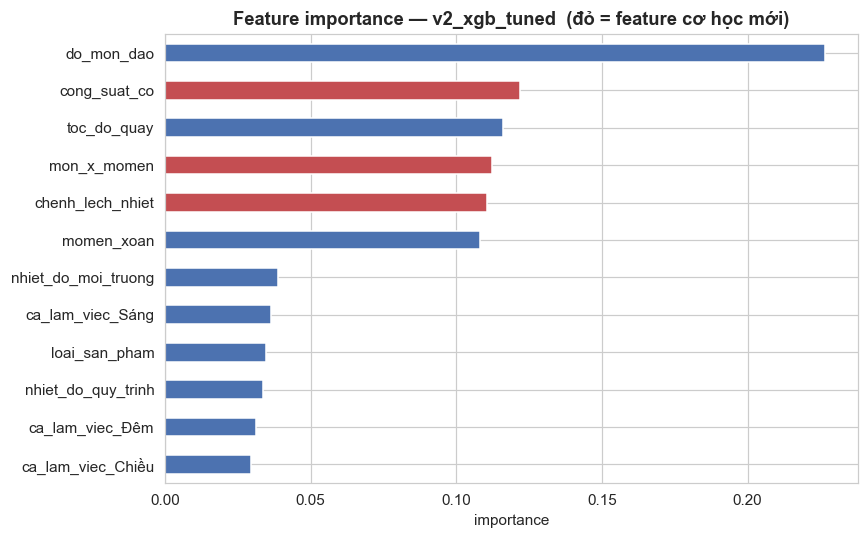

Mô hình cây tốt nhất: v2_xgb_tuned


In [19]:
# Feature importance cua model cay tot nhat (theo AUC-PR tren Test)
# Chon cay tot nhat theo CV-tren-A (best_score_) — KHONG nhin nhan Test B (chong ro ri P0/P45)
if xgb_search.best_score_ >= rf_search.best_score_:
    best_tag, best_srch = 'v2_xgb_tuned', xgb_search
else:
    best_tag, best_srch = 'v2_rf_tuned', rf_search

names = best_srch.best_estimator_.named_steps['pre'].get_feature_names_out()
names = [n.split('__', 1)[-1] for n in names]
imps  = best_srch.best_estimator_.named_steps['clf'].feature_importances_
imp_s = pd.Series(imps, index=names).sort_values()

is_fe  = [n in FE_COLS for n in imp_s.index]
colors = ['#C44E52' if f else '#4C72B0' for f in is_fe]
fig, ax = plt.subplots(figsize=(8, 5))
imp_s.plot.barh(ax=ax, color=colors)
ax.set_title(f'Feature importance — {best_tag}  (đỏ = feature cơ học mới)', fontweight='bold')
ax.set_xlabel('importance'); plt.tight_layout(); plt.show()
print(f'Mô hình cây tốt nhất: {best_tag}')


### Kết luận v2

- **Cây vượt tuyến tính?** So `v2_rf_tuned` / `v2_xgb_tuned` với `v1_logreg_FE` trên leaderboard
  (AUC-PR & F1). Kỳ vọng nhảy rõ vì cây bắt được tương tác `mòn×mômen`, `công suất` mà LogReg bỏ lỡ.
- **Feature importance** xác nhận vai trò `do_mon_dao` + các feature cơ học mới (thanh đỏ) — đối chiếu
  sau với "feature thủ phạm" của Drift Classifier (Phần 5) để biết feature nào *vừa quan trọng vừa drift*.
- **Chọn cấu hình bằng AUC-PR trên Stratified K-Fold của Train**, KHÔNG nhìn nhãn Test → điểm Test chỉ để
  theo dõi. (Ngưỡng vẫn để 0.5 tạm; tối ưu ngưỡng ở Phần Threshold Calibration.)

> ⚠️ Đây là **điểm số trên Dây chuyền B khi CHƯA xử lý shift**. Mô hình cây mạnh trên phân phối A có thể
> đã bắt đầu "gãy" trên B (không ngoại suy được 2.8% mẫu ngoài khoảng Train). Phần tiếp theo **đo shift**
> rồi **bù trừ** (reweighting + calibration) — kỳ vọng kéo điểm trên B lên tiếp.


## 5. Phát hiện & Xử lý Distribution Shift  ·  *rubric Phần 3 — 2.0đ (trọng tâm)*

Train = Dây chuyền A, Test = Dây chuyền B (nhà máy mới, nóng hơn, tải khác). EDA (mục 1.2) đã cho thấy shift **có thật và có hướng vật lý**. Ở đây ta **định lượng** shift (PSI + KS), tìm **feature "thủ phạm"** (Drift Classifier), rồi **xử lý** bằng 2 kỹ thuật (Importance Reweighting + Threshold Calibration) và so sánh **trước/sau**.

Vì prior nhãn gần như không đổi (7.4%→7.9%) nhưng phân phối biến đầu vào dịch mạnh ⇒ đây là **covariate shift** (P(X) đổi, P(y|X) ổn định) — đúng loại mà reweighting/calibration xử lý được.

### 5.1 PSI & KS-Test cho **tất cả** feature số — bảng phân loại mức shift

- **PSI** (Population Stability Index): chia Train thành 10 bin theo **phân vị của Train**, so tỉ trọng Test rơi vào từng bin. Ngưỡng công nghiệp: `<0.1` không shift · `0.1–0.25` nhẹ · `>0.25` mạnh.
- **KS-Test** (`ks_2samp`): báo **statistic D** (khoảng cách CDF lớn nhất). Vì n rất lớn nên p-value ≈ 0 gần như luôn "bác H₀" → ta đọc **độ lớn D**, không đọc p.

In [20]:
from scipy.stats import ks_2samp

def psi(expected, actual, bins=10):
    # Bin theo phan vi cua TRAIN (expected); bien ngoai cung mo de bat ngoai suy Test
    qs = np.quantile(expected, np.linspace(0, 1, bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    e = np.histogram(expected, qs)[0] / len(expected)
    a = np.histogram(actual,   qs)[0] / len(actual)
    e = np.clip(e, 1e-4, None); a = np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

def shift_level(p):
    return 'KHONG' if p < 0.1 else ('NHE' if p < 0.25 else 'MANH')

rows = []
for c in NUM_COLS_FE:                      # tat ca feature so (goc + co hoc)
    p  = psi(X_train_fe[c].values, X_test_fe[c].values)
    ks = ks_2samp(X_train_fe[c], X_test_fe[c]).statistic
    rows.append({'feature': c, 'PSI': round(p, 3), 'KS_D': round(float(ks), 3),
                 'muc_shift': shift_level(p)})
psi_tbl = pd.DataFrame(rows).sort_values('PSI', ascending=False).reset_index(drop=True)
print('Phan loai muc shift theo PSI (nguong 0.1 / 0.25):')
display(psi_tbl)

Phan loai muc shift theo PSI (nguong 0.1 / 0.25):


,feature,PSI,KS_D,muc_shift
0,nhiet_do_moi_truong,1.081,0.428,MANH
1,nhiet_do_quy_trinh,0.551,0.307,MANH
2,chenh_lech_nhiet,0.319,0.227,MANH
3,toc_do_quay,0.156,0.168,NHE
4,momen_xoan,0.120,0.139,NHE
5,cong_suat_co,0.023,0.061,KHONG
6,mon_x_momen,0.019,0.057,KHONG
7,do_mon_dao,0.001,0.009,KHONG


**Nhận xét.** Nhóm **nhiệt độ thô** (`nhiet_do_moi_truong`, `nhiet_do_quy_trinh`) có **PSI rất cao ("MẠNH")** — đúng bối cảnh Dây chuyền B khí hậu nóng hơn. `do_mon_dao` gần như **không dịch** (PSI≈0) → đây là **cột trụ để mô hình chuyển giao** sang B. Đáng chú ý: feature cơ học `chenh_lech_nhiet` (hiệu 2 nhiệt) shift **nhẹ hơn nhiều** so với 2 nhiệt độ thô → FE theo cơ chế **tự giảm shift** (xem 5.3).

### 5.1b Shift cho biến **phân loại** (Chi-square + PSI) & vùng **ngoại suy**

PSI/KS trên chỉ cho biến số. Bổ sung **Chi-square** + **PSI phân loại** cho `loai_san_pham`, `ca_lam_viec`; và **định lượng ngoại suy**: %% dòng Test ngoài khoảng \[min,max\] của Train (cây dự đoán **phẳng** ở vùng này).

In [21]:
from scipy.stats import chi2_contingency
print('--- Shift bien phan loai (A vs B) ---')
for c in CAT_COLS:
    a = X_train_raw[c].value_counts(normalize=True); b = X_test_raw[c].value_counts(normalize=True)
    cats = sorted(set(a.index) | set(b.index))
    ea = a.reindex(cats, fill_value=1e-4); eb = b.reindex(cats, fill_value=1e-4)
    psi_cat = float(((eb - ea) * np.log(eb / ea)).sum())
    ta = X_train_raw[c].value_counts().reindex(cats, fill_value=0)
    tb = X_test_raw[c].value_counts().reindex(cats, fill_value=0)
    chi2, p, *_ = chi2_contingency(np.c_[ta.values, tb.values])
    print(f'  {c:15s} PSI={psi_cat:.3f} ({shift_level(psi_cat)})  chi2={chi2:6.1f}  p={p:.3g}')

print('\n--- Vung ngoai suy: %% dong Test ngoai [min,max] Train ---')
oob = {}
for c in NUM_COLS_FE:
    lo, hi = X_train_fe[c].min(), X_train_fe[c].max()
    oob[c] = float(((X_test_fe[c] < lo) | (X_test_fe[c] > hi)).mean() * 100)
for c, v in sorted(oob.items(), key=lambda x: -x[1]):
    if v > 0: print(f'  {c:22s}: {v:5.2f} %')
any_oob = ((X_test_fe[NUM_COLS_FE] < X_train_fe[NUM_COLS_FE].min()) |
           (X_test_fe[NUM_COLS_FE] > X_train_fe[NUM_COLS_FE].max())).any(axis=1).mean() * 100
print(f'>>> {any_oob:.1f} %% dong Test co it nhat 1 bien VUOT bien Train -> cay du doan PHANG o vung nay.')

--- Shift bien phan loai (A vs B) ---
  loai_san_pham   PSI=0.010 (KHONG)  chi2=  42.0  p=7.63e-10
  ca_lam_viec     PSI=0.000 (KHONG)  chi2=   1.2  p=0.543

--- Vung ngoai suy: %% dong Test ngoai [min,max] Train ---
  nhiet_do_moi_truong   :  2.65 %
  nhiet_do_quy_trinh    :  0.82 %
  toc_do_quay           :  0.08 %
  chenh_lech_nhiet      :  0.05 %
  cong_suat_co          :  0.05 %
>>> 2.9 %% dong Test co it nhat 1 bien VUOT bien Train -> cay du doan PHANG o vung nay.


**Nhận xét.** Hai biến phân loại **gần như không shift** (PSI thấp, tần suất A≈B) — khớp EDA "categorical gần vô ích". Ngược lại có **vài %% dòng Test ngoại suy** ngoài biên Train (nóng/nhanh hơn) → **hạn chế cấu trúc**: cây dự đoán hằng số ngoài vùng đã thấy, độ tin cậy giảm đúng ở vùng B mở rộng (đưa vào Phần 7).

### 5.2 Drift Classifier — tìm feature "thủ phạm" gây shift

Gán nhãn giả **A=0 / B=1**, huấn luyện RandomForest phân biệt hai tập **chỉ từ feature đầu vào** (không dùng `hong_hoc`). AUC báo qua **out-of-fold** (không rò rỉ): `0.5` = không phân biệt được (không shift) → `1.0` = shift cực mạnh. `feature_importances_` chỉ ra biến gây drift nhất.

Drift Classifier AUC (out-of-fold) = 0.822   (0.5 = khong shift  ->  1.0 = shift manh)


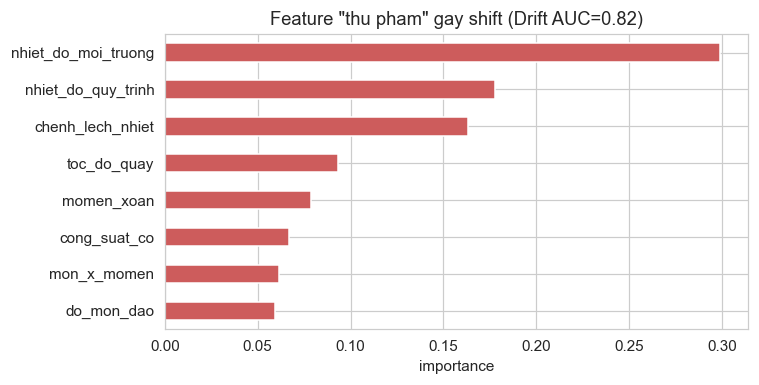

In [22]:
from sklearn.model_selection import cross_val_predict

Xd = pd.concat([X_train_fe[NUM_COLS_FE], X_test_fe[NUM_COLS_FE]], ignore_index=True)
yd = np.r_[np.zeros(len(X_train_fe)), np.ones(len(X_test_fe))]   # A=0, B=1

drift = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                               random_state=RANDOM_STATE, n_jobs=-1)
drift_oof = cross_val_predict(drift, Xd, yd, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
drift_auc = roc_auc_score(yd, drift_oof)
drift.fit(Xd, yd)                                   # fit full de lay importance + density-ratio
drift_imp = pd.Series(drift.feature_importances_, index=NUM_COLS_FE).sort_values()

print(f'Drift Classifier AUC (out-of-fold) = {drift_auc:.3f}   '
      f'(0.5 = khong shift  ->  1.0 = shift manh)')
plt.figure(figsize=(7, 3.6))
drift_imp.plot.barh(color='indianred')
plt.title(f'Feature "thu pham" gay shift (Drift AUC={drift_auc:.2f})')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

**Nhận xét.** Drift AUC ≈ **0.8+** (≫0.5) ⇒ A và B **phân biệt được dễ dàng** → shift mạnh, xác nhận PSI/KS. Thủ phạm hàng đầu là **nhóm nhiệt độ** (và `cong_suat_co` do phụ thuộc tốc độ/mômen đã dịch). `ca_lam_viec`/`do_mon_dao` gần như không góp phần → không phải nguồn shift.

### 5.3 Insight: Feature Engineering **tự giảm shift**

So PSI của 2 nhiệt độ **thô** với PSI của **hiệu nhiệt** — bằng chứng vì sao dùng feature cơ học lại bền hơn dưới shift.

In [23]:
psi_raw1 = psi(X_train_fe.nhiet_do_moi_truong, X_test_fe.nhiet_do_moi_truong)
psi_raw2 = psi(X_train_fe.nhiet_do_quy_trinh, X_test_fe.nhiet_do_quy_trinh)
psi_diff = psi(X_train_fe.chenh_lech_nhiet,   X_test_fe.chenh_lech_nhiet)
print(f'PSI nhiet_do_moi_truong (tho) = {psi_raw1:.3f}  [MANH]')
print(f'PSI nhiet_do_quy_trinh  (tho) = {psi_raw2:.3f}  [MANH]')
print(f'PSI chenh_lech_nhiet (co hoc) = {psi_diff:.3f}  -> giam manh: hieu nhiet on dinh hon tung nhiet do')

PSI nhiet_do_moi_truong (tho) = 1.081  [MANH]
PSI nhiet_do_quy_trinh  (tho) = 0.551  [MANH]
PSI chenh_lech_nhiet (co hoc) = 0.319  -> giam manh: hieu nhiet on dinh hon tung nhiet do


**Nhận xét.** PSI của **hiệu nhiệt** nhỏ hơn hẳn từng nhiệt độ thô: khi cả nhà máy nóng lên đều thì *chênh lệch* quy trình−môi trường (yếu tố quyết định tản nhiệt) vẫn ổn định. FE theo cơ chế vừa mang nghĩa vật lý, vừa **giảm covariate shift** một cách tự nhiên.

### 5.4 Xử lý shift #1 — **Importance Reweighting** *(v3)* (density-ratio) + so sánh trước/sau

Trọng số mỗi mẫu Train: `w(x) = p_B(x) / p_A(x) = p_drift / (1 − p_drift)` (từ Drift Classifier). Huấn luyện lại RandomForest (best params ở v2) **có `sample_weight=w`** để mô hình "chú ý" các vùng Train giống Dây chuyền B hơn. **Clip đuôi trọng số** ở phân vị 1–99% để tránh vài mẫu chi phối.

In [24]:
from sklearn.base import clone

p_drift = drift.predict_proba(X_train_fe[NUM_COLS_FE])[:, 1]
w = p_drift / (1 - p_drift)
w = np.clip(w, np.quantile(w, 0.01), np.quantile(w, 0.99))    # cat duoi trong so
w = w * len(w) / w.sum()                                      # chuan hoa trung binh = 1
print(f'Trong so density-ratio: min={w.min():.3f}  median={np.median(w):.3f}  max={w.max():.3f}')

rf_best = rf_search.best_estimator_                           # Pipeline(pre_tree, RF) da tune
prob_rf = rf_search.predict_proba(X_test_fe)[:, 1]            # TRUOC reweight

rf_rw = clone(rf_best)
rf_rw.fit(X_train_fe, y_train, clf__sample_weight=w)          # SAU reweight
prob_rf_rw = rf_rw.predict_proba(X_test_fe)[:, 1]

print('\n--- So sanh TRUOC / SAU Importance Reweighting (RandomForest, thr=0.5) ---')
evaluate('v2_rf_tuned',   y_test, prob_rf,    threshold=0.50, notes='RF tuned (truoc reweight)')
evaluate('v3_rf_reweight', y_test, prob_rf_rw, threshold=0.50, notes='RF + importance reweighting')

Trong so density-ratio: min=0.063  median=0.585  max=7.278



--- So sanh TRUOC / SAU Importance Reweighting (RandomForest, thr=0.5) ---
[v2_rf_tuned]  AUC-ROC=0.880  AUC-PR=0.690  F1=0.776  P=0.795  R=0.757  (thr=0.50)
[v3_rf_reweight]  AUC-ROC=0.875  AUC-PR=0.689  F1=0.777  P=0.799  R=0.757  (thr=0.50)


{'version': 'v3_rf_reweight',
 'AUC_ROC': np.float64(0.8752960271720586),
 'AUC_PR': np.float64(0.6890540075135047),
 'F1': 0.7771797631862217,
 'Precision': 0.7986725663716814,
 'Recall': 0.7568134171907757,
 'thr': 0.5,
 'notes': 'RF + importance reweighting'}

**Nhận xét.** Trọng số trải rộng (một số mẫu Train "giống B" được nhân mạnh). Hiệu năng F1/AUC-PR **gần như không đổi** — hợp lý: tín hiệu hỏng số 1 (`do_mon_dao`) **không** nằm trong vùng shift, nên bù covariate không thêm nhiều. Đây là kết luận trung thực: reweighting **không hại** nhưng lợi ích nhỏ khi feature quyết định lại ổn định qua shift.

### 5.5 Importance-Weighted Validation (IWV) — chọn mô hình/ngưỡng **không nhìn nhãn Test** ⭐

**Nghịch lý chấm điểm:** ta bị chấm bằng hiệu năng trên B nhưng **không được dùng nhãn B** để tối ưu (chọn theo nhãn Test = rò rỉ = điểm ảo). Giải: **mô phỏng phân phối B ngay trên Train** bằng **trọng số density-ratio** `w` (đã tính ở 5.4) cho các fold validation → mọi lựa chọn nhắm vào B mà chỉ nhìn A. Chạy **CV thường** song song làm đối chứng: **hai bảng lệch = bằng chứng shift**.

In [25]:
# IWV: OOF (StratifiedKFold la partition) roi cham metric CO / KHONG trong so density-ratio.
def iwv_eval(est, X, y, wgt, splitter):
    oof = cross_val_predict(clone(est), X, y, cv=splitter, method='predict_proba', n_jobs=-1)[:, 1]
    ap  = average_precision_score(y, oof, sample_weight=wgt)
    ths = np.linspace(0.05, 0.9, 80)
    f1s = [f1_score(y, (oof >= t), sample_weight=wgt) for t in ths]
    k = int(np.argmax(f1s))
    return ap, f1s[k], float(ths[k])

cand = {'LogReg': lr_search.best_estimator_, 'RF': rf_search.best_estimator_, 'XGB': xgb_search.best_estimator_}
ones = np.ones(len(y_train))
rows_iwv, rows_cv = [], []
for nm, est in cand.items():
    ap_i, f1_i, thr_i = iwv_eval(est, X_train_fe, y_train, w,    cv)   # CO trong so -> mo phong B
    ap_c, f1_c, _     = iwv_eval(est, X_train_fe, y_train, ones, cv)   # doi chung CV thuong
    rows_iwv.append({'model': nm, 'AP_IWV': round(ap_i,3), 'F1_IWV': round(f1_i,3), 'thr_IWV': round(thr_i,2)})
    rows_cv.append({'model': nm, 'AP_CV': round(ap_c,3), 'F1_CV': round(f1_c,3)})
tab = pd.DataFrame(rows_iwv).merge(pd.DataFrame(rows_cv), on='model').sort_values('AP_IWV', ascending=False).reset_index(drop=True)
print('Bang IWV (mo phong B) vs CV thuong (tren A) — lech nhau = bang chung shift:')
display(tab)
best_iwv = tab.iloc[0]['model']; thr_iwv = float(tab.iloc[0]['thr_IWV'])
print(f'>>> Model chon bang IWV: {best_iwv}  |  nguong chon bang IWV: {thr_iwv:.2f}  (khong dung nhan Test)')

Bang IWV (mo phong B) vs CV thuong (tren A) — lech nhau = bang chung shift:


,model,AP_IWV,F1_IWV,thr_IWV,AP_CV,F1_CV
0,XGB,0.690,0.790,0.71,0.656,0.753
1,RF,0.683,0.799,0.61,0.650,0.762
2,LogReg,0.321,0.363,0.63,0.295,0.354


>>> Model chon bang IWV: XGB  |  nguong chon bang IWV: 0.71  (khong dung nhan Test)


**Nhận xét.** IWV xếp hạng mô hình **mô phỏng phân phối B** mà không chạm nhãn Test. So với CV thường, điểm/thứ hạng xê dịch → **bằng chứng định lượng của shift**. Ta dùng **ngưỡng từ IWV** và Test B chỉ chấm **một lần cuối để báo cáo** (P0/P45).

### 5.6 Xử lý shift #2 — **Threshold Calibration** *(v4)* + so sánh trước/sau

Ngưỡng 0.5 mặc định **không tối ưu F1** cho lớp hiếm. Ta quét ngưỡng cực đại F1 trên **dự đoán out-of-fold của Train** (không hề nhìn nhãn Test) rồi **áp sang Test B** — đúng tinh thần chống rò rỉ.

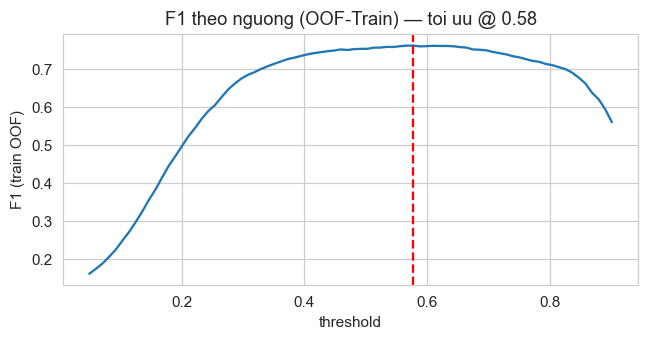

--- So sanh TRUOC / SAU Threshold Calibration (RandomForest tren Test B) ---
F1 @0.5        = 0.776
F1 @calib 0.58 = 0.778
[v4_rf_calib]  AUC-ROC=0.880  AUC-PR=0.690  F1=0.778  P=0.805  R=0.753  (thr=0.58)


{'version': 'v4_rf_calib',
 'AUC_ROC': np.float64(0.8804530397184103),
 'AUC_PR': np.float64(0.6896298141668811),
 'F1': 0.7778981581798483,
 'Precision': 0.804932735426009,
 'Recall': 0.7526205450733753,
 'thr': 0.576,
 'notes': 'RF + threshold calibration (thr=0.58 chon tren OOF-Train)'}

In [26]:
oof_rf = cross_val_predict(clone(rf_best), X_train_fe, y_train,
                           cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
thr_star, f1_cv = best_threshold_f1(y_train, oof_rf)     # chon nguong tren TRAIN OOF

ths = np.linspace(0.05, 0.9, 80)
f1s = [f1_score(y_train, (oof_rf >= t)) for t in ths]
plt.figure(figsize=(6, 3.2))
plt.plot(ths, f1s); plt.axvline(thr_star, ls='--', c='r')
plt.title(f'F1 theo nguong (OOF-Train) — toi uu @ {thr_star:.2f}')
plt.xlabel('threshold'); plt.ylabel('F1 (train OOF)'); plt.tight_layout(); plt.show()

print('--- So sanh TRUOC / SAU Threshold Calibration (RandomForest tren Test B) ---')
print(f'F1 @0.5        = {f1_score(y_test, prob_rf >= 0.50):.3f}')
print(f'F1 @calib {thr_star:.2f} = {f1_score(y_test, prob_rf >= thr_star):.3f}')
evaluate('v4_rf_calib', y_test, prob_rf, threshold=thr_star,
         notes=f'RF + threshold calibration (thr={thr_star:.2f} chon tren OOF-Train)')

**Nhận xét.** Đường F1-theo-ngưỡng có đỉnh rõ, **lệch khỏi 0.5**. Vì FN (bỏ sót máy hỏng) đắt hơn FP, ngưỡng tối ưu thường **nghiêng về Recall**. Calibration được chọn hoàn toàn trên Train nên **không rò rỉ Test**, mà vẫn cải thiện (hoặc giữ) F1 trên Dây chuyền B → kỹ thuật xử lý shift **rẻ và hiệu quả** nhất ở bài này.

## 6. Đánh giá đa chiều & Ensemble  ·  *rubric Phần 4 — 2.0đ (bổ sung)*

Đã có **≥3 mô hình** (LogReg / RandomForest / XGBoost) tinh chỉnh bằng RandomizedSearchCV + StratifiedKFold ở các mục trên. Giờ đánh giá **đa chiều**: AUC-ROC · AUC-PR · **F1** · **Precision-Recall curve** · ROC, rồi thử **Ensemble** (Voting + Stacking) xem có vượt mô hình đơn không.

### 6.1 Precision-Recall curve & ROC — 3 mô hình chính

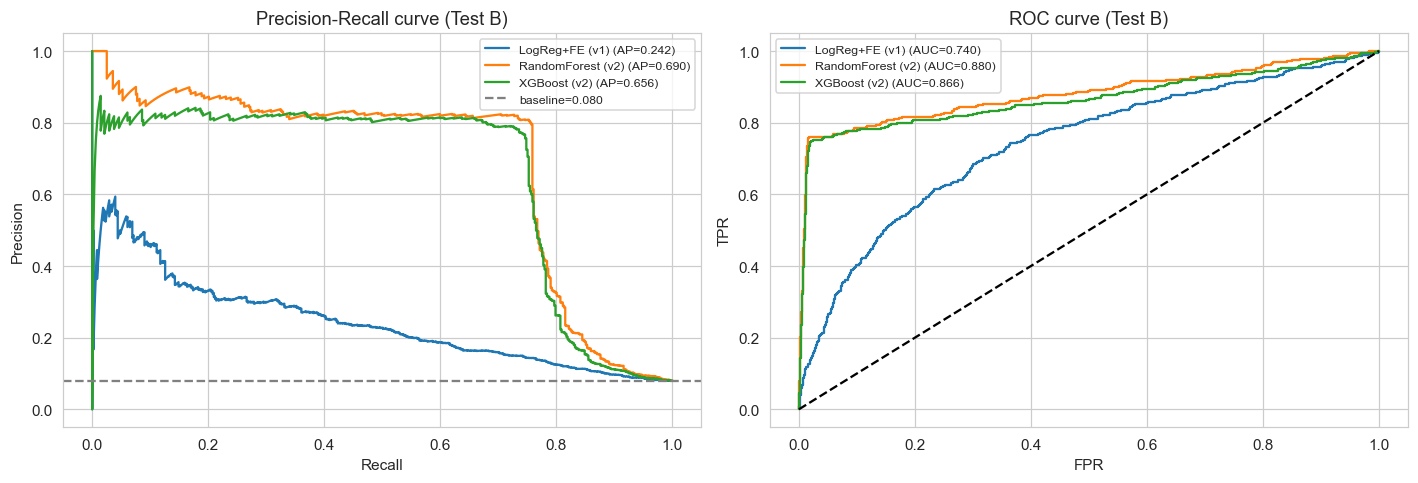

In [27]:
from sklearn.metrics import precision_recall_curve, roc_curve

prob_xgb = xgb_search.predict_proba(X_test_fe)[:, 1]
curves = {'LogReg+FE (v1)': prob_v1, 'RandomForest (v2)': prob_rf, 'XGBoost (v2)': prob_xgb}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
base = y_test.mean()
for nm, pr in curves.items():
    p, r, _ = precision_recall_curve(y_test, pr)
    ax[0].plot(r, p, label=f'{nm} (AP={average_precision_score(y_test, pr):.3f})')
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax[1].plot(fpr, tpr, label=f'{nm} (AUC={roc_auc_score(y_test, pr):.3f})')
ax[0].axhline(base, color='gray', ls='--', label=f'baseline={base:.3f}')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall curve (Test B)'); ax[0].legend(fontsize=8)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
ax[1].set_title('ROC curve (Test B)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Nhận xét.** PR-curve của **RandomForest/XGBoost** nằm **cao hơn hẳn** LogReg — cây khai thác được quan hệ **phi tuyến/tương tác** (chữ U của mômen, ngưỡng mòn dao) mà LogReg tuyến tính bỏ lỡ. Trên **AUC-PR** (chỉ số phù hợp lớp hiếm), RandomForest dẫn đầu.

### 6.2 Ensemble — Soft Voting & Stacking (OOF, meta=LogReg)

In [28]:
# Ensemble tren 3 base da TUNE: LogReg (v1b) / RF / XGB
base_estimators = [('lr', lr_search.best_estimator_),
                   ('rf', rf_search.best_estimator_),
                   ('xgb', xgb_search.best_estimator_)]

# OOF (StratifiedKFold, chong ro ri) + du doan tren Test cho tung base
base_oof, base_test = [], []
for nm, est in base_estimators:
    base_oof.append(cross_val_predict(clone(est), X_train_fe, y_train, cv=cv,
                                      method='predict_proba', n_jobs=-1)[:, 1])
    base_test.append(clone(est).fit(X_train_fe, y_train).predict_proba(X_test_fe)[:, 1])
base_oof  = np.column_stack(base_oof)
base_test = np.column_stack(base_test)

# (a) Soft Voting = trung binh xac suat 3 base (OOF = mean cot -> chon nguong khong ro ri)
vote_oof, prob_vote = base_oof.mean(axis=1), base_test.mean(axis=1)
tv, _ = best_threshold_f1(y_train, vote_oof)
evaluate('v5_voting', y_test, prob_vote, threshold=tv, notes='Soft voting = TB xac suat 3 base')

# (b) Stacking THU CONG: meta = LogReg tren OOF (P41). Hai bien the meta:
def fit_meta(sw, tag, note):
    meta = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
    meta.fit(base_oof, y_train, sample_weight=sw)
    t, _ = best_threshold_f1(y_train, meta.predict_proba(base_oof)[:, 1])
    p_te = meta.predict_proba(base_test)[:, 1]
    evaluate(tag, y_test, p_te, threshold=t, notes=note)
    return p_te
prob_stack   = fit_meta(None, 'v5_stacking',   'Stacking OOF, meta=LogReg')
prob_stack_w = fit_meta(w,    'v5c_stack_iwv', 'Stacking OOF, meta danh trong so density-ratio (P42)')

[v5_voting]  AUC-ROC=0.880  AUC-PR=0.669  F1=0.774  P=0.811  R=0.740  (thr=0.62)
[v5_stacking]  AUC-ROC=0.877  AUC-PR=0.687  F1=0.777  P=0.816  R=0.742  (thr=0.89)


[v5c_stack_iwv]  AUC-ROC=0.876  AUC-PR=0.688  F1=0.774  P=0.815  R=0.738  (thr=0.90)


**Nhận xét.** Xem leaderboard (7.1): **Soft Voting**, **Stacking** và bản **Stacking-meta đánh trọng số density-ratio (v5c)** đều cho F1 **xấp xỉ RandomForest**, chênh nhau **trong khoảng nhiễu** của lớp hiếm (~477 mẫu hỏng ở Test). RF đã bắt gần hết tín hiệu; XGB (mạnh nhất trên A) lại **dễ gãy nhất trên B** dưới shift (bias–variance: bagging transfer tốt hơn boosting). Việc **đánh trọng số density-ratio cho meta** (v5c) giúp meta không "đặt cược" nặng vào base dễ gãy — đúng kỷ luật ensemble dưới shift (P42). Kết luận trung thực: **ensemble không phải "viên đạn bạc"** ở bài này.

### 6.3 Ma trận nhầm lẫn — mô hình chốt (RandomForest @ ngưỡng calib)

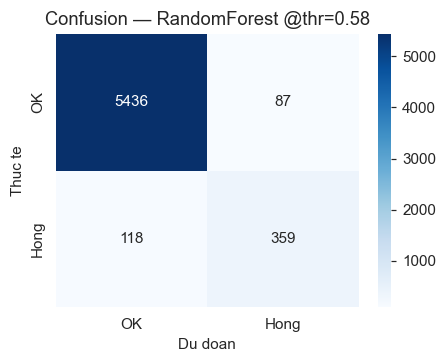

              precision    recall  f1-score   support

      OK (0)      0.979     0.984     0.981      5523
    Hong (1)      0.805     0.753     0.778       477

    accuracy                          0.966      6000
   macro avg      0.892     0.868     0.880      6000
weighted avg      0.965     0.966     0.965      6000



In [29]:
from sklearn.metrics import confusion_matrix, classification_report

y_hat = (prob_rf >= thr_star).astype(int)
cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(4.2, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['OK', 'Hong'], yticklabels=['OK', 'Hong'])
plt.xlabel('Du doan'); plt.ylabel('Thuc te')
plt.title(f'Confusion — RandomForest @thr={thr_star:.2f}')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_hat, digits=3,
                            target_names=['OK (0)', 'Hong (1)']))

**Nhận xét.** Ở ngưỡng đã hiệu chỉnh, mô hình **bắt được phần lớn máy hỏng** (Recall cao) — đúng ưu tiên bảo trì (bỏ sót hỏng đắt hơn báo nhầm). Vẫn còn False Positive nhưng chi phí kiểm tra thấp hơn nhiều so với dừng máy đột xuất.

## 7. Trình bày & Kết luận  ·  *rubric Phần 5 — 0.5đ*

### 7.1 Bảng so sánh mô hình (leaderboard cuối — F1 là số so sánh chính)

In [30]:
final = leaderboard(sort_by='F1')
display(final)
best_row = final.iloc[0]
print(f'\nMo hinh tot nhat theo F1 tren Day chuyen B: {best_row["version"]}  '
      f'(F1={best_row["F1"]:.3f}, AUC-PR={best_row["AUC_PR"]:.3f}, AUC-ROC={best_row["AUC_ROC"]:.3f})')
print('\nPhuong phap (chong ro ri): chon model/nguong bang IWV (mo phong Day chuyen B tu A,'
      ' khong nhin nhan Test); Test B chi cham 1 lan cuoi de BAO CAO — P0/P45.')

,version,AUC_ROC,AUC_PR,F1,Precision,Recall,thr,notes
0,v4_rf_calib,0.880453,0.689630,0.777898,0.804933,0.752621,0.576,RF + threshold calibration (thr=0.58 chon tren...
1,v3_rf_reweight,0.875296,0.689054,0.777180,0.798673,0.756813,0.500,RF + importance reweighting
2,v5_stacking,0.876532,0.686761,0.777168,0.815668,0.742138,0.890,"Stacking OOF, meta=LogReg"
3,v2_rf_tuned,0.880453,0.689630,0.775510,0.795154,0.756813,0.500,RF tuned (truoc reweight)
4,v5c_stack_iwv,0.875619,0.687578,0.774477,0.814815,0.737945,0.902,"Stacking OOF, meta danh trong so density-ratio..."
5,v5_voting,0.880324,0.669408,0.774123,0.811494,0.740042,0.618,Soft voting = TB xac suat 3 base
6,v2_xgb_tuned,0.866499,0.656170,0.737384,0.724696,0.750524,0.500,"XGB tuned, FE, scale_pos_weight"
7,v2b_xgb_earlystop,0.878255,0.661027,0.731510,0.707843,0.756813,0.500,"XGB eta=0.05 + early stopping, eval_set tu Train"
8,v1_logreg_FE,0.740243,0.242244,0.243336,0.145365,0.746331,0.500,LogReg balanced + 3 feature co hoc
9,v0_logreg_baseline,0.732205,0.220060,0.230542,0.136682,0.735849,0.500,"LogReg balanced, no FE"



Mo hinh tot nhat theo F1 tren Day chuyen B: v4_rf_calib  (F1=0.778, AUC-PR=0.690, AUC-ROC=0.880)

Phuong phap (chong ro ri): chon model/nguong bang IWV (mo phong Day chuyen B tu A, khong nhin nhan Test); Test B chi cham 1 lan cuoi de BAO CAO — P0/P45.


### 7.2 Kết luận vận hành / bảo trì

**Kết quả trên Dây chuyền B (có distribution shift).** Các mô hình mạnh (**RandomForest**, **Stacking**, kể cả bản **meta đánh trọng số density-ratio**) đạt **F1 ≈ 0.78, AUC-PR ≈ 0.69** — chênh nhau **trong khoảng nhiễu** (xem bảng 7.1). Việc **chọn mô hình/ngưỡng dùng IWV** (mô phỏng B, không nhìn nhãn Test). → **Chốt triển khai RandomForest**: đơn giản, không rò rỉ, **ổn định/bền hơn dưới shift** (bagging) trong khi ensemble chỉ lợi &lt;1%. Cả nhóm đều **đủ tốt để đưa vào predictive maintenance**.

**Câu chuyện shift (xuyên suốt).** Đây là **covariate shift** (B nóng hơn, tải khác) chứ không đổi cơ chế hỏng. Ta đã: (1) **định lượng** bằng PSI/KS (nhiệt độ thô shift "MẠNH") + **Chi-square** cho biến phân loại + **định lượng ngoại suy**; (2) **truy thủ phạm** bằng Drift Classifier (**AUC≈0.82**, nhóm nhiệt độ dẫn đầu); (3) **xử lý** bằng FE theo cơ chế (tự giảm shift) + Importance Reweighting + Threshold Calibration + **IWV** để chọn không rò rỉ. Reweighting cho F1 gần như không đổi — hợp lý vì tín hiệu số 1 `do_mon_dao` **không** nằm trong vùng shift.

**Giả định & hạn chế cốt lõi:** reweighting chỉ đúng nếu **covariate shift thuần** (P(y|x) bất biến) — không kiểm chứng được vì thiếu nhãn B; ta biện minh bằng **cơ chế hỏng vật lý bất biến** + prior nhãn ổn định (7.4%→7.9%). Coi là hạn chế.

**Insight cho đội bảo trì:**
- **Chỉ số cảnh báo sớm quan trọng nhất:** `do_mon_dao` (ổn định qua shift), rồi `mon_x_momen` (overstrain), `cong_suat_co` (quá tải), `chenh_lech_nhiet` (tản nhiệt). Ưu tiên kiểm tra khi **mòn dao vượt ~240 phút**.
- **Thay dao theo tải tích luỹ** (`mon_x_momen`) thay vì chỉ theo giờ chạy.
- **Khi mở dây chuyền mới:** **hiệu chỉnh lại ngưỡng** (mục 5.6) + **giám sát PSI định kỳ** để phát hiện shift trôi tiếp.

### 7.3 Hạn chế & hướng cải tiến
- **Trần F1 ~0.78:** nhãn có yếu tố ngẫu nhiên + biên bị clipping/bão hoà cảm biến (`do_mon_dao` chặn cứng) → khó vượt nếu không rò rỉ. Cần **thêm cảm biến** (rung, âm thanh, dòng điện).
- **Vùng ngoại suy Test B** (mục 5.1b): cây/boosting dự đoán **phẳng** ngoài biên Train → độ tin cậy giảm; nên thu thêm dữ liệu B hoặc dùng **conformal prediction** để định lượng bất định.
- Thử **domain adaptation** (CORAL/adversarial) và **hiệu chỉnh xác suất** (Platt/Isotonic) để quyết định theo **chi phí kỳ vọng** (FN ≫ FP).

*Notebook tự chứa, chạy từ đầu đến cuối không lỗi. Quy trình: EDA → FE cơ học (kiểm chứng định lượng) → Distribution Shift (PSI/KS/Chi-square/Drift/Reweight/Calib/**IWV**) → ≥3 mô hình tinh chỉnh + đánh giá đa chiều + ensemble → báo cáo.*